# Multi-Stage Attack Detection Using Random Forest (Baseline v3.1)

## Fix dari v3:
- Stage 2 F1 anjlok karena IP-split menempatkan **semua** password & mitm di test
  (0 di train → model gak pernah lihat → classify Other)
- Train Stage 2 cuma dari **2 src_ip** → gak generalize

## Solusi: **Type-Aware IP Split**
- Untuk setiap **attack type**, pastikan ada IP di train DAN test
- Ini menjamin setiap jenis serangan terwakili di kedua set
- Baru setelah itu, volume-based whale filtering seperti v2

# SETUP

---
## 0. Imports

In [1]:
import re
import warnings

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_curve, auc
)

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier


warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


---
## 1. Load & Prepare

In [2]:
df = pd.read_csv('train_test_network.csv')
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df['dst_port'] = pd.to_numeric(df['dst_port'], errors='coerce').fillna(0)
df['ts'] = pd.to_numeric(df['ts'], errors='coerce')

STAGE_MAP = {
    'normal': 0, 'scanning': 1,
    'xss': 2, 'ddos': 2, 'dos': 2, 'injection': 2, 'mitm': 2, 'password': 2,
    'backdoor': 3, 'ransomware': 3,
}
df['stage'] = df['type'].map(STAGE_MAP)
assert df['stage'].isna().sum() == 0

print(f"Shape: {df.shape}")
print(f"\nStage: {df['stage'].value_counts().sort_index().to_dict()}")
print(f"Types: {df['type'].value_counts().to_dict()}")


Shape: (170591, 48)

Stage: {0: 96395, 1: 23702, 2: 49469, 3: 1025}
Types: {'normal': 96395, 'scanning': 23702, 'injection': 16310, 'xss': 15231, 'dos': 14547, 'ddos': 2047, 'password': 1034, 'ransomware': 886, 'mitm': 300, 'backdoor': 139}


In [3]:
min_range = df[df['stage'] == 3]['ts'].min()
max_range = df[df['stage'] == 3]['ts'].max()

for i in df[df['stage'] == 3]:
    min_range = df[df['stage'] == 3]['ts'].min()
    max_range = df[df['stage'] == 3]['ts'].max()

    mask = (df['stage'] == 3) & (df['ts'] != min_range) & (df['ts'] != max_range)
    df.loc[mask, 'ts'] = np.random.RandomState(42).uniform(min_range, max_range, size=mask.sum())

---
### Attack Chain Analysis

In [4]:
dst_s1 = set(df[df['stage']==1]['dst_ip'].unique())
dst_s2 = set(df[df['stage']==2]['dst_ip'].unique())
dst_s3 = set(df[df['stage']==3]['dst_ip'].unique())
print(f"Dst IPs: S1={len(dst_s1)} | S2={len(dst_s2)} | S3={len(dst_s3)}")
print(f"S1∩S2={len(dst_s1&dst_s2)} | S1∩S2∩S3={len(dst_s1&dst_s2&dst_s3)}")

rows = []
for ip in sorted(dst_s1 | dst_s2 | dst_s3):
    s1=len(df[(df['dst_ip']==ip)&(df['stage']==1)])
    s2=len(df[(df['dst_ip']==ip)&(df['stage']==2)])
    s3=len(df[(df['dst_ip']==ip)&(df['stage']==3)])
    if s1>0 or s3>0: rows.append({'dst_ip':ip,'S1':s1,'S2':s2,'S3':s3})
print(f"\nKey targets:")
print(pd.DataFrame(rows).sort_values('S3',ascending=False).head(15).to_string(index=False))

Dst IPs: S1=46 | S2=161 | S3=13
S1∩S2=38 | S1∩S2∩S3=5

Key targets:
         dst_ip  S1  S2  S3
  192.168.1.193 200 128 508
   192.168.1.33 200   0 335
     121.0.0.42   0   0  49
  103.38.120.36   0  23  48
  34.230.157.88   1   9  26
    192.168.1.1 200 300  18
    13.55.50.68   0   0   9
   192.168.1.37   0   0   9
  52.11.124.117   1  14   8
  203.14.129.10   0   0   5
192.168.159.152   0  24   4
  34.236.82.205   0   5   4
    192.168.1.6   2   7   2
   192.168.1.79 200 104   0
255.255.255.255   4  24   0


In [5]:
len(df[df['stage'] == 3]['dst_ip'].unique())

13

### Check stage timestamps

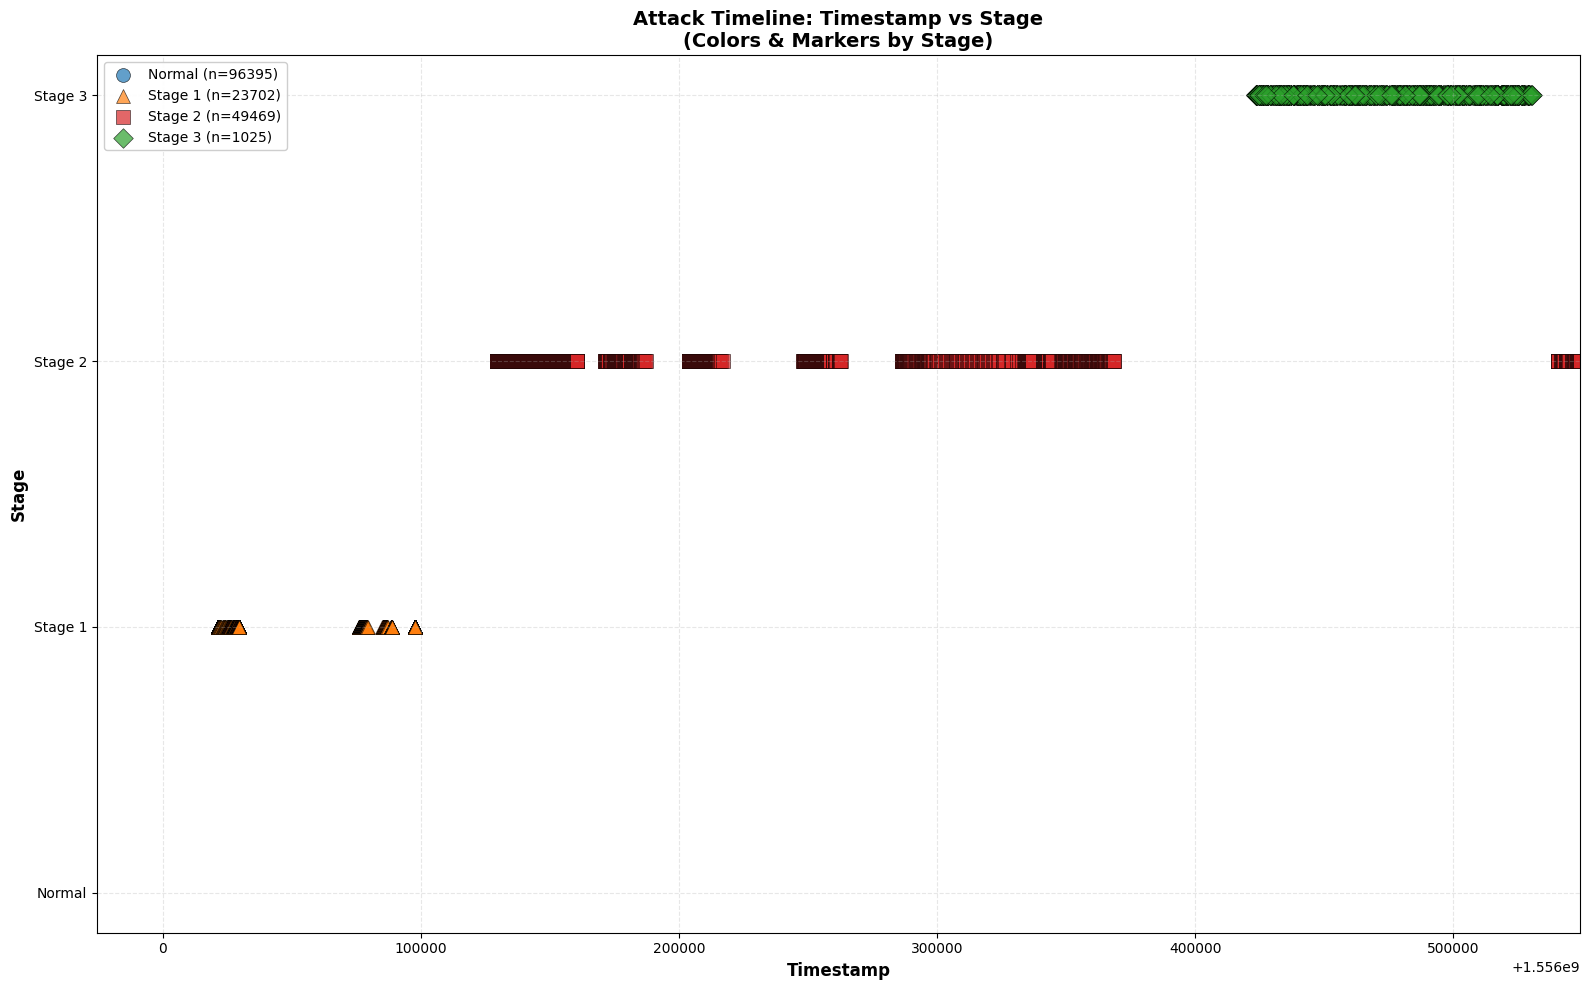


Visualization Summary:
  Total events: 170591
  Timestamp range: 1554198358 to 1556549129
  Display range: 1555974395 to 1556549129
  Stage distribution:
    Normal:  96395 ( 56.5%)
    Stage 1:  23702 ( 13.9%)
    Stage 2:  49469 ( 29.0%)
    Stage 3:   1025 (  0.6%)


In [6]:
# Temporal-Stage Dot Graph: Timestamp vs Stage (marked & colored by Stage)
df_plot = df.dropna(subset=['ts']).copy()

# Map stages to colors, markers, and names
stage_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728', 3: '#2ca02c'}  # blue, orange, red, green
stage_names = {0: 'Normal', 1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3'}
stage_markers = {0: 'o', 1: '^', 2: 's', 3: 'D'}  # circle, triangle, square, diamond

# Find timestamp limits: start just before first non-normal stage
first_stage_ts = df_plot[df_plot['stage'] > 0]['ts'].min()
ts_margin = (df_plot['ts'].max() - df_plot['ts'].min()) * 0.02  # 2% margin
ts_start = first_stage_ts - ts_margin if first_stage_ts else df_plot['ts'].min()
ts_end = df_plot['ts'].max()

# Create figure
fig, ax = plt.subplots(figsize=(16, 10))

# Plot each stage separately for legend
for stage in sorted(df_plot['stage'].unique()):
    stage_data = df_plot[df_plot['stage'] == stage]
    ax.scatter(stage_data['ts'], stage_data['stage'], 
               c=stage_colors[stage], 
               marker=stage_markers[stage],
               s=100, alpha=0.7, 
               label=f'{stage_names[stage]} (n={len(stage_data)})',
               edgecolors='black', linewidth=0.5)

# Configure axes
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Stage', fontsize=12, fontweight='bold')
ax.set_title('Attack Timeline: Timestamp vs Stage\n(Colors & Markers by Stage)', 
             fontsize=14, fontweight='bold')

# Set Y-axis ticks and labels to stages
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([stage_names[s] for s in [0, 1, 2, 3]])

# Set X-axis limits
ax.set_xlim(ts_start, ts_end)

# Format X-axis
ax.ticklabel_format(style='plain', axis='x')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')

# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig('timeline_stage_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization Summary:")
print(f"  Total events: {len(df_plot)}")
print(f"  Timestamp range: {df_plot['ts'].min():.0f} to {df_plot['ts'].max():.0f}")
print(f"  Display range: {ts_start:.0f} to {ts_end:.0f}")
print(f"  Stage distribution:")
for s in [0, 1, 2, 3]:
    count = (df_plot['stage'] == s).sum()
    pct = 100 * count / len(df_plot)
    print(f"    {stage_names[s]}: {count:>6} ({pct:>5.1f}%)")

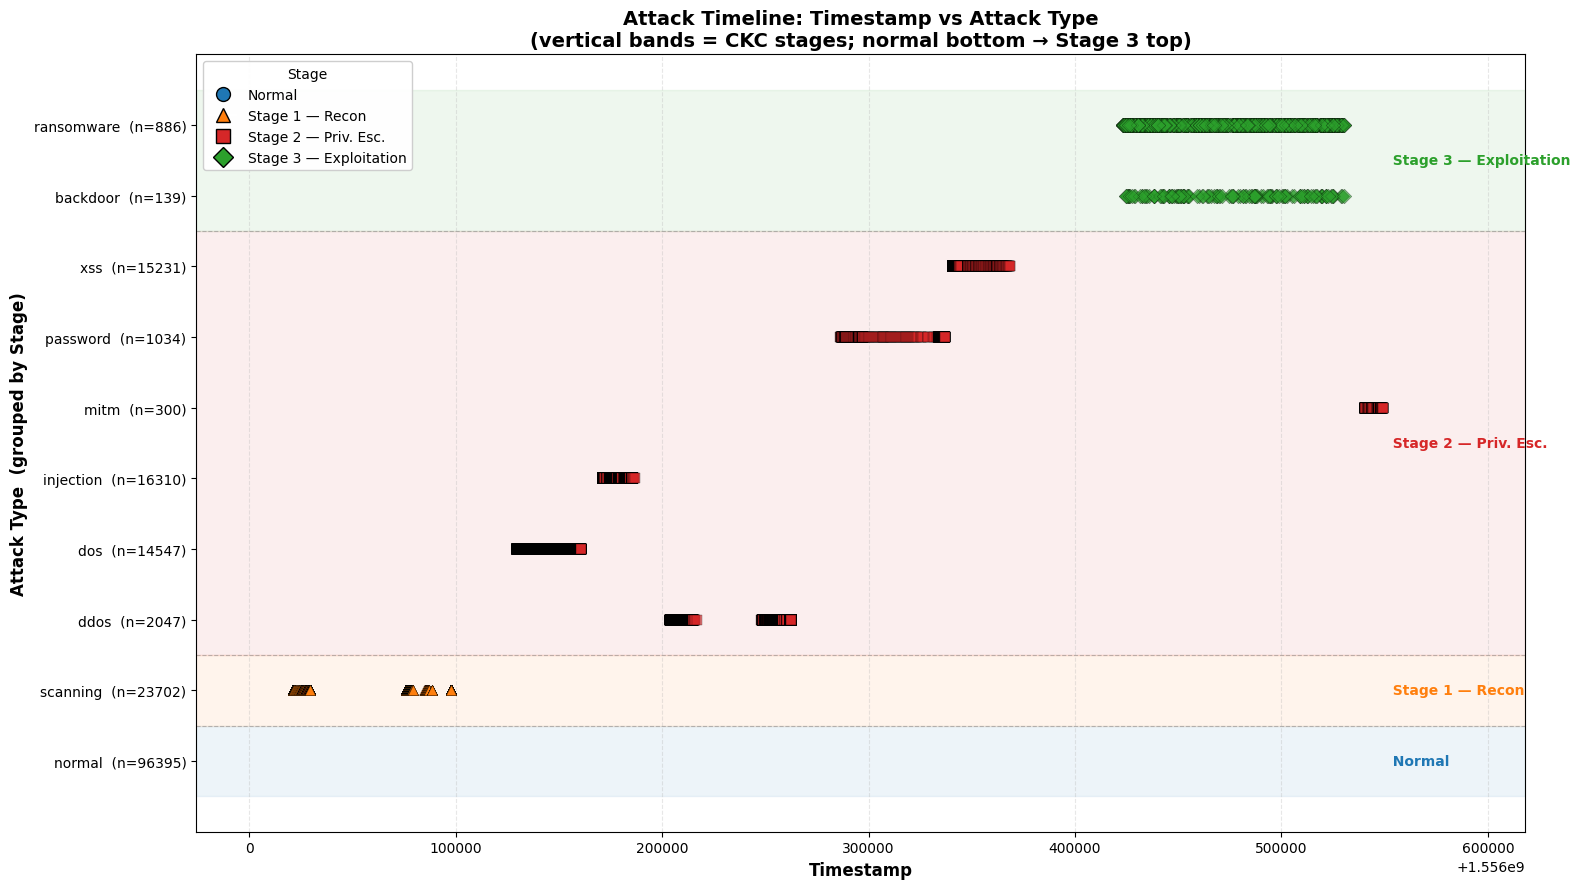

In [7]:
# Temporal-Stage Dot Graph: Timestamp vs Attack TYPE, grouped into Stage bands
df_plot = df.dropna(subset=['ts']).copy()

stage_colors  = {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728', 3: '#2ca02c'}
stage_names   = {0: 'Normal', 1: 'Stage 1 — Recon', 2: 'Stage 2 — Priv. Esc.', 3: 'Stage 3 — Exploitation'}
stage_markers = {0: 'o', 1: '^', 2: 's', 3: 'D'}

# --- order attack types by stage (normal bottom → stage 3 top) ---
TYPE_STAGE = {t: df_plot.loc[df_plot['type'] == t, 'stage'].iloc[0] for t in df_plot['type'].unique()}
types_by_stage = {s: sorted([t for t, st in TYPE_STAGE.items() if st == s]) for s in [0, 1, 2, 3]}
y_order = []                      # bottom → top
for s in [0, 1, 2, 3]:
    y_order.extend(types_by_stage[s])
ypos = {t: i for i, t in enumerate(y_order)}

SHOW_NORMAL_CLUSTER = False       # True = include the far-left normal cluster in view

first_stage_ts = df_plot[df_plot['stage'] > 0]['ts'].min()
margin = (df_plot['ts'].max() - df_plot['ts'].min()) * 0.02
ts_start = (df_plot['ts'].min() if SHOW_NORMAL_CLUSTER
            else (first_stage_ts - margin if pd.notna(first_stage_ts) else df_plot['ts'].min()))
ts_end = df_plot['ts'].max()

fig, ax = plt.subplots(figsize=(16, 9))

# --- shaded horizontal bands per stage + right-side label + separators ---
for s in [0, 1, 2, 3]:
    ys = [ypos[t] for t in types_by_stage[s]]
    if not ys:
        continue
    lo, hi = min(ys) - 0.5, max(ys) + 0.5
    ax.axhspan(lo, hi, color=stage_colors[s], alpha=0.08, zorder=0)
    ax.text(ts_end, (lo + hi) / 2, f'  {stage_names[s]}', va='center', ha='left',
            fontsize=10, fontweight='bold', color=stage_colors[s])
    if s > 0:
        ax.axhline(lo, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)

# --- plot points: y = type, color/marker = stage ---
for s in [0, 1, 2, 3]:
    for t in types_by_stage[s]:
        d = df_plot[df_plot['type'] == t]
        ax.scatter(d['ts'], [ypos[t]] * len(d), c=stage_colors[s], marker=stage_markers[s],
                   s=55, alpha=0.6, edgecolors='black', linewidth=0.3, zorder=3)

ax.set_yticks(range(len(y_order)))
ax.set_yticklabels([f'{t}  (n={(df_plot["type"] == t).sum()})' for t in y_order], fontsize=10)
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Attack Type  (grouped by Stage)', fontsize=12, fontweight='bold')
ax.set_title('Attack Timeline: Timestamp vs Attack Type\n(vertical bands = CKC stages; normal bottom → Stage 3 top)',
             fontsize=14, fontweight='bold')
ax.ticklabel_format(style='plain', axis='x')
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

handles = [plt.Line2D([0], [0], marker=stage_markers[s], color='w', markerfacecolor=stage_colors[s],
                      markeredgecolor='black', markersize=10, label=stage_names[s]) for s in [0, 1, 2, 3]]
ax.legend(handles=handles, loc='upper left', fontsize=10, framealpha=0.95, title='Stage')

# right margin so the band labels fit
ax.set_xlim(ts_start, ts_end + (ts_end - ts_start) * 0.12)

plt.tight_layout()
plt.savefig('timeline_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. DATA  PREPROCESSING

### 2.1. Feature Engineering

*Notes: Some future / test IP information can get into the dataset, however it is okay because :
    - in actual implementation, every new flow will update model's information, thus leading to the newest attributes being taken into account


═══════════════════════════════════════════════════════════════════════════
NEW FLOW-LEVEL FEATURES  — drop-in replacement for the feature block in Cell 15
═══════════════════════════════════════════════════════════════════════════
These follow the MECE framework:
    Bucket 1 — Scan behavior   (Stage 1 signal): breadth of contact
    Bucket 2 — Exploit behavior(Stage 2 signal): per-flow / windowed anomaly

- All features are computed in feature_engineering() BEFORE the pre-split drop, so they only use raw columns (src_ip, ts, dst_ip, service, conn_state, src_bytes, dst_bytes, dst_pkts). Output columns are new names, so nothing in DROP_COLS_PRESPLIT / DROP_COLS_AFTERSPLIT touches them, and get_dummies leaves them alone (numeric). aggregate_by_dst_ip() will roll them up to Stage 3 for free. → NO pipeline changes required.

- No Future Data leakage, because all functions either:
    1. Does not require cross-row data hence will not use any information other than an isolated row to calculate the new feature for that row
    2. Use historical cross-row data, for example: if row is at time t, then the used rows will be [t-x : t]
═══════════════════════════════════════════════════════════════════════════

In [8]:
ABNORMAL_CONN_STATES = {
    'S0', 'REJ', 'RSTO', 'RSTR', 'RSTOS0', 'RSTRH', 'SH', 'SHR', 'OTH',
    'S1', 'S2', 'S3',
}



# ── BUCKET 1: SCAN BEHAVIOR ──────────────────────────────────────────────────

def dst_ip_fanout_10s(df):
    """IP fanout: number of unique dst_ip a src_ip contacts in a 10s window.
    High fanout = horizontal scanning across hosts (ATT&CK T1595/T1018)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'dst_ip']):
        ret['dst_ip_fanout_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip', 'dst_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')

    # HACK ANTI-STRING: factorize IP strings to int codes so rolling stays fast
    temp['dst_ip_code'] = pd.factorize(temp['dst_ip'])[0]

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    fanout = temp.groupby('src_ip', sort=False)['dst_ip_code'].rolling('10s').apply(lambda x: len(set(x)), raw=False)
    temp['val'] = fanout.values
    ret['dst_ip_fanout_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret

def dst_port_fanout_10s(df):
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'dst_port']):
        ret['dst_port_fanout_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip', 'dst_port']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')

    # HACK ANTI-STRING: Ubah string/teks jadi ID angka unik biar Pandas ga rewel
    temp['dst_port_code'] = pd.factorize(temp['dst_port'])[0]

    temp = temp.sort_values(['src_ip', 'dt'])

    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset

    temp = temp.set_index('dt_unique')

    fanout = temp.groupby('src_ip', sort=False)['dst_port_code'].rolling('10s').apply(lambda x: len(set(x)), raw=False)

    temp['val'] = fanout.values
    ret['dst_port_fanout_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def conn_count_10s(df):
    ret = df.copy()
    if 'ts' not in ret.columns or 'src_ip' not in ret.columns:
        ret['conn_count_10s'] = 0.0
        return ret
    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')
    counts = temp.groupby('src_ip', sort=False)['ts'].rolling('10s').count()
    temp['val'] = counts.values
    ret['conn_count_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def no_response_ratio_10s(df):
    """Fraction of a src_ip's flows in a 10s window that got no response back
    (dst_bytes == 0 AND dst_pkts == 0). High ratio = blind probing (T1595)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'dst_bytes', 'dst_pkts']):
        ret['no_response_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    # per-flow no-response indicator
    temp['no_resp'] = ((ret['dst_bytes'] == 0) & (ret['dst_pkts'] == 0)).astype(int).values

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    ratio = temp.groupby('src_ip', sort=False)['no_resp'].rolling('10s').mean()
    temp['val'] = ratio.values
    ret['no_response_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def service_entropy_10s(df):
    """Shannon entropy (bits) of the services a src_ip touches in a 10s window.
    High entropy = sweeping many services = service discovery (T1046)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'service']):
        ret['service_entropy_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip', 'service']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp['service_code'] = pd.factorize(temp['service'])[0]

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    def _entropy(x):
        p = pd.Series(x).value_counts(normalize=True)
        return float(-(p * np.log2(p)).sum())

    ent = temp.groupby('src_ip', sort=False)['service_code'].rolling('10s').apply(_entropy, raw=False)
    temp['val'] = ent.values
    ret['service_entropy_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret

def is_no_response(df):
    ret = df.copy()
    ret['is_no_response'] = ((ret['dst_bytes'] == 0) & (ret['dst_pkts'] == 0)).astype(int)
    return ret

def is_rej_udp(df):
    ret = df.copy()
    ret['is_rej_udp'] = (
        (ret['conn_state'] == 'REJ') & (ret['proto'] == 'udp')
    ).astype(int)
    return ret

# def is_abnormal_conn(df):
#     ret = df.copy()
#     ret['is_abnormal_conn'] = ret['conn_state'].isin(ABNORMAL_CONN_STATES).astype(int)
#     return ret

# ── BUCKET 2: EXPLOIT BEHAVIOR ───────────────────────────────────────────────

def bytes_ratio(df):
    """Payload asymmetry per flow: src_bytes / (dst_bytes + 1).
    >> 1 = pushing a payload (injection/exploit, T1190); ~0 = pulling data."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['src_bytes', 'dst_bytes']):
        ret['bytes_ratio'] = 0.0
        return ret

    s = pd.to_numeric(ret['src_bytes'], errors='coerce').fillna(0)  # src_bytes has mixed types
    d = pd.to_numeric(ret['dst_bytes'], errors='coerce').fillna(0)
    ret['bytes_ratio'] = (s / (d + 1.0)).astype(float)
    return ret

# def bytes_per_pkt_src(df):
#     """Mean outbound packet size: src_bytes / (src_pkts + 1). Tiny = scan/flood,
#     large = exploit payload. Division — trees can't derive it from the columns."""
#     ret = df.copy()
#     s = pd.to_numeric(ret.get('src_bytes', 0), errors='coerce').fillna(0)
#     p = pd.to_numeric(ret.get('src_pkts', 0), errors='coerce').fillna(0)
#     ret['bytes_per_pkt_src'] = (s / (p + 1.0)).astype(float)
#     return ret

def abnormal_conn_ratio_10s(df):
    """Fraction of a src_ip's flows in a 10s window ending in an abnormal
    conn_state (REJ/RSTO/S0/OTH/...). High ratio = aborted/abused handshakes
    typical of exploit attempts and DoS (T1190/T1499)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'conn_state']):
        ret['abnormal_conn_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp['abn'] = ret['conn_state'].isin(ABNORMAL_CONN_STATES).astype(int).values

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    ratio = temp.groupby('src_ip', sort=False)['abn'].rolling('10s').mean()
    temp['val'] = ratio.values
    ret['abnormal_conn_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def burst_ratio_10s(df):
    """Burstiness: (conns in last 1s) / (conns in last 10s) for a src_ip.
    ~1.0 = all traffic crammed into a 1s spike = flooding (DoS/DDoS, T1498)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip']):
        ret['burst_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    g = temp.groupby('src_ip', sort=False)['ts']
    c1 = g.rolling('1s').count().values
    c10 = g.rolling('10s').count().values
    temp['val'] = c1 / (c10 + 1e-9)
    ret['burst_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret



############  Function to call  ##############

def feature_engineering(df):
    ret = df.copy()
    
    # Bucket 1: scan behavior
    ret = dst_ip_fanout_10s(ret)
    ret = dst_port_fanout_10s(ret)
    ret = conn_count_10s(ret)
    ret = is_no_response(ret)
    ret = no_response_ratio_10s(ret)
    ret = is_rej_udp(ret)
    # ret = is_abnormal_conn(ret)
    ret = service_entropy_10s(ret)
    
    # Bucket 2: exploit behavior
    ret = bytes_ratio(ret)
    ret = abnormal_conn_ratio_10s(ret)
    ret = burst_ratio_10s(ret)
    # ret = bytes_per_pkt_src(ret)


    return ret


def get_dummies (df):
    ret = df.copy()
    # Identify categorical columns (exclude src_ip, dst_ip, stage, and numeric columns)
    categorical_cols = [c for c in ret.columns 
                       if ret[c].dtype == 'object' and c not in ['src_ip', 'dst_ip', 'stage', 'type', 'label']]
    
    # One-hot encode only the categorical columns, preserving IPs
    if categorical_cols:
        ret = pd.get_dummies(ret, columns=categorical_cols, drop_first=True, dtype=int)
    
    return ret


### 2.2. Feature Selection

In [9]:
DROP_COLS_PRESPLIT = [ 'src_port', 'dst_port',
    'dns_query', 'http_uri', 'http_user_agent',
    'ssl_subject', 'ssl_issuer', 'weird_addl',
    'dns_rejected', 'ssl_established', 'ssl_resumed',
    'weird_notice', 'dns_AA', 'dns_RD', 'dns_RA',
    'ssl_version', 'ssl_cipher',
    'http_trans_depth', 'http_method', 'http_version',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name', 'http_referrer', 'sequence_type',
    'src_ip_bytes',
]
remaining = [c for c in df.columns if c not in DROP_COLS_PRESPLIT]
print(f"Presplit Features ({len(remaining)}): {remaining}")

DROP_COLS_AFTERSPLIT = [
    # Presplit features
    'src_ip', 'ts',    
    
    # label derivatives
    'type', 'label'
    ]

rem = [c for c in df.columns if c not in DROP_COLS_AFTERSPLIT and c not in DROP_COLS_PRESPLIT]
print(f"After-split Features ({len(rem)}): {rem}") 


Presplit Features (19): ['ts', 'src_ip', 'dst_ip', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'label', 'type', 'stage']
After-split Features (15): ['dst_ip', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'stage']


In [10]:

def feature_selection_presplit (df, drop_cols=DROP_COLS_PRESPLIT):
    ret = df.copy()
    return ret.drop(columns=drop_cols, errors='ignore')

def feature_selection_aftersplit (df, drop_cols=DROP_COLS_AFTERSPLIT):
    ret = df.copy()
    return ret.drop(columns=drop_cols, errors='ignore')

## 3. DATA SPLITTING

### 3.1. TIME SPLITTING WITH FLOW-AWARE SPLIT


In [11]:
def timesplit(df, guard=1):
    """PREDICTION-grade time split (v6).

    Cutoff is placed JUST BEFORE the first stage-3 flow:
        cutoff = min(ts | stage==3) - guard
    so df_past contains ZERO stage-3 flows. df_past is therefore pure
    recon/exploit history used to build entity FEATURES; df_future is where
    stage-3 victimisation happens and is used ONLY to derive LABELS.

    This is what turns Stage 3 from a DETECTOR (reads the attack flows) into a
    PREDICTOR (forecasts the attack from prior behaviour). Nothing about the
    stage-3 attack is visible in the feature window.
    """
    df_temporal = df.dropna(subset=['ts']).copy()

    first_s3 = df_temporal.loc[df_temporal['stage'] == 3, 'ts'].min()
    cutoff   = first_s3 - guard

    df_future = df_temporal[df_temporal['ts'] >= cutoff].copy()
    df_past   = df_temporal[df_temporal['ts'] <  cutoff].copy()

    print(f"First stage-3 ts : {first_s3:.0f}")
    print(f"Cutoff timestamp : {cutoff:.0f}  (first_s3 - {guard})")
    print(f"df_past rows     : {len(df_past)}")
    print(f"df_future rows   : {len(df_future)}")
    print(f"Stage 3 in past  : {(df_past['stage'] == 3).sum()}  (MUST be 0)")
    print(f"Stage 3 in future: {(df_future['stage'] == 3).sum()}")
    print(f"Future S3 victim dst_ips: {df_future.loc[df_future['stage']==3,'dst_ip'].nunique()}")

    assert (df_past['stage'] == 3).sum() == 0, \
        "Stage-3 leaked into df_past — increase `guard`."
    return df_past, df_future

# df_past , df_future = timesplit(df)


---
### 3.2. Type-Aware IP Split (NEW)

Problem v2/v3:
IP split per-stage bisa menempatkan seluruh attack type di satu set:
- Train Stage 2: 2 IP → hanya injection, xss, dos, ddos
- Test Stage 2: 10 IP → password, mitm, dll → **gak pernah dilihat model**

Solusi:
Split per **attack type**, bukan per stage:
1. Untuk setiap unique `type`, kumpulkan semua `src_ip` yang melakukannya
2. Untuk setiap type, pastikan minimal 1 IP masuk test DAN sisanya di train
3. IP "whale" (>30% rows dari type itu) wajib train
4. Ini menjamin SETIAP attack type ada di train DAN test

In [12]:
def type_aware_ip_split(df, test_ratio=0.3, normal_test_ratio = 0.2, test_ratio_stage_3 = 0.5, random_state=42, verbose=True):
    """
    Type-Aware IP Split: Ensures every attack type is represented in both train and test.
    
    Parameters:
    -----------
    df : DataFrame
        Input data with columns: 'src_ip', 'type', 'stage'
    test_ratio : float
        Target ratio of flows in test set (default 0.3)
    normal_test_ratio : float
        Target ratio of normal flows in test set (default 0.2)
    test_ratio_stage_3 : float
        Target ratio of flows in test set for stage 3 (default 0.5)
    random_state : int
        Random seed for reproducibility (default 42)
    verbose : bool
        Print detailed split information (default True)
    
    Returns:
    --------
    df_train, df_test : DataFrames
        Train and test splits with no overlapping IPs
    """
    rng = np.random.RandomState(random_state)
    test_ips = set()
    train_ips = set()

    if verbose:
        print("=" * 60)
        print("TYPE-AWARE IP SPLIT")
        print("=" * 60)

    # ── Step 1: Per attack type, split IPs ──────────────────────
    attack_types = [t for t in df['type'].unique() if t != 'normal']

    for atype in sorted(attack_types):
        type_df = df[df['type'] == atype]
        type_total = len(type_df)
        target_test = int(test_ratio * type_total)
        ip_counts = type_df['src_ip'].value_counts().reset_index()
        ip_counts.columns = ['src_ip', 'flow_count']
        # if atype in ['backdoor', 'ransomware']:
        #     target_test = int(test_ratio_stage_3 * type_total)
        #     selected_s3_ips.append(type_df['src_ip'].unique()[:target_test//2])
        #     test_ips.update(selected_s3_ips[-1])
        if atype in ['backdoor', 'ransomware']:
            target_test = int(test_ratio_stage_3 * type_total)
            cur = 0; selected = []
            for _, row in ip_counts.iterrows():  # ip_counts already sorted descending by flow_count
                selected.append(row['src_ip'])
                cur += row['flow_count']
                if cur >= target_test:
                    break
            test_ips.update(selected)
            if verbose:
                print(f"  {atype:12s}: {type_total:>6} flows | "
                    f"Test IPs: {len(selected)} ({cur} flows)")        
        
        if atype not in ['backdoor', 'ransomware']:
            # Whale filtering: IP dengan >30% dari type ini → wajib train
            whale_threshold = 0.3 * type_total
            whales = ip_counts[ip_counts['flow_count'] > whale_threshold]
            small_fish = ip_counts[ip_counts['flow_count'] <= whale_threshold]
            
            # Whale IPs → train
            for wip in whales['src_ip']:
                train_ips.add(wip)
            
            # Dari small fish, pilih IPs untuk test
            shuffled = small_fish.sample(frac=1, random_state=rng).reset_index(drop=True)
            cur = 0; selected = []
            for _, row in shuffled.iterrows():
                if row['src_ip'] in train_ips:
                    continue
                if cur + row['flow_count'] <= target_test:
                    selected.append(row['src_ip'])
                    cur += row['flow_count']
                if cur >= target_test:
                    break
            
            # Fallback: kalau gak ada yang terpilih, ambil 1 small fish terkecil
            if not selected and len(small_fish) > 0:
                for _, row in small_fish.sort_values('flow_count').iterrows():
                    if row['src_ip'] not in train_ips:
                        selected.append(row['src_ip'])
                        cur += row['flow_count']
                        break
            
            test_ips.update(selected)
            if verbose:
                print(f"  {atype:12s}: {type_total:>6} flows | Whales: {len(whales)} | "
                    f"Test IPs: {len(selected)} ({cur} flows)")

    # ── Step 2: Normal-only IPs ─────────────────────────────────
    all_attack_ips = set(df[df['stage'] != 0]['src_ip'].unique())
    pure_normal = df[(df['stage'] == 0) & (~df['src_ip'].isin(all_attack_ips))]
    normal_target = int(normal_test_ratio * len(pure_normal))

    nip = pure_normal['src_ip'].value_counts().reset_index()
    nip.columns = ['src_ip', 'flow_count']
    sn = nip[nip['flow_count'] <= normal_target].sample(frac=1, random_state=rng)
    c = 0; sel_n = []
    for _, row in sn.iterrows():
        if c + row['flow_count'] <= normal_target:
            sel_n.append(row['src_ip']); c += row['flow_count']
        if c >= normal_target: break
    test_ips.update(sel_n)
    if verbose:
        print(f"  {'normal':12s}: {len(pure_normal):>6} flows | Test IPs: {len(sel_n)} ({c} flows)")

    # ── Step 3: Enforce no-overlap ──────────────────────────────
    test_ips -= train_ips

    # ── Step 4: Split ───────────────────────────────────────────
    df_train = df[~df['src_ip'].isin(test_ips)].copy()
    df_test = df[df['src_ip'].isin(test_ips)].copy()

    if verbose:
        print(f"\nTrain: {len(df_train)} ({df_train['src_ip'].nunique()} IPs)")
        print(f"Test:  {len(df_test)} ({df_test['src_ip'].nunique()} IPs)")
        print(f"IP overlap: {len(set(df_train['src_ip']) & set(df_test['src_ip']))}")

        # ── Validation: every type in both sets ─────────────────────
        print(f"\nType coverage validation:")
        all_ok = True
        for atype in sorted(attack_types):
            in_train = len(df_train[df_train['type'] == atype])
            in_test = len(df_test[df_test['type'] == atype])
            status = "OK" if (in_train > 0 and in_test > 0) else "MISSING!"
            if in_train == 0 or in_test == 0:
                all_ok = False
            print(f"  {atype:12s}: train={in_train:>6}, test={in_test:>5}  [{status}]")

        if all_ok:
            print("\n  ALL TYPES present in both train and test!")
        else:
            print("\n  WARNING: Some types missing from train or test")

        print(f"\nStage distribution:")
        for s in [0, 1, 2, 3]:
            tr = (df_train['stage']==s).sum(); te = (df_test['stage']==s).sum()
            print(f"  Stage {s}: train={tr:>6}, test={te:>6}")

    return df_train, df_test

---
# DATA PIPELINE

## 4. PIPELINE EXECUTION

In [13]:
df.columns

Index(['ts', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_referrer', 'http_version',
       'http_request_body_len', 'http_response_body_len', 'http_status_code',
       'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types',
       'weird_name', 'weird_addl', 'weird_notice', 'label', 'type', 'stage',
       'sequence_type'],
      dtype='object')

### 4.1. Initial Pipeline Execution

In [14]:
# Data Preprocessing
df = feature_engineering(df)
df = feature_selection_presplit(df)
df = get_dummies(df)

# Execute Time Split
df_past , df_future = timesplit(df)

# Execute IP Split
df_train_past, df_test_past = type_aware_ip_split(df_past, test_ratio=0.3, test_ratio_stage_3=0.5, random_state=42, verbose=True)

First stage-3 ts : 1556423390
Cutoff timestamp : 1556423389  (first_s3 - 1)
df_past rows     : 169266
df_future rows   : 1325
Stage 3 in past  : 0  (MUST be 0)
Stage 3 in future: 1025
Future S3 victim dst_ips: 13
TYPE-AWARE IP SPLIT
  ddos        :   2047 flows | Whales: 1 | Test IPs: 5 (469 flows)
  dos         :  14547 flows | Whales: 1 | Test IPs: 2 (1728 flows)
  injection   :  16310 flows | Whales: 1 | Test IPs: 7 (982 flows)
  password    :   1034 flows | Whales: 2 | Test IPs: 3 (105 flows)
  scanning    :  23702 flows | Whales: 1 | Test IPs: 17 (4930 flows)
  xss         :  15231 flows | Whales: 1 | Test IPs: 2 (6 flows)
  normal      :  83683 flows | Test IPs: 27 (16736 flows)

Train: 141695 (38 IPs)
Test:  27571 (46 IPs)
IP overlap: 0

Type coverage validation:
  ddos        : train=  1767, test=  280  [OK]
  dos         : train= 12819, test= 1728  [OK]
  injection   : train= 15336, test=  974  [OK]
  password    : train=   929, test=  105  [OK]
  scanning    : train= 18772, t

*Note: dst_ip is dropped here instead of earlier because we need it for dataset creation in the stage 3 model, but we don't want it as a feature for the model to prevent overfitting to specific IPs.

### 4.1.5. ENTITY-LEVEL FEATURE CREATION

DECLARE TABLE FOR ENTITY-LEVEL FEATURE CREATION:
1. Entity-level features are created here before feature_selection_aftersplit because it requires:
    - *Presplit features*: 'src_ip', 'ts', 'dst_ip', 'stage'


In [15]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ENTITY-LEVEL  (replaces Cell 34)
# ════════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# TIME-FREE ENTITY-LEVEL FEATURES (v4.3) — same structure as flow-level:
#   one function per feature, threaded through a wrapper (ret = feature(df, ret)).
# Entity features read from the flow frame (df_flow) and accumulate into a
# per-dst_ip frame (ret); only the features aggregate_by_dst_ip CANNOT make are
# here. DROPPED vs v4.2: all ts features and all label-reading (`stage`) features.
# ═══════════════════════════════════════════════════════════════════════════
 
#### EF RAW

def _gini(x):
    a = np.asarray(x, dtype=float)
    if a.size == 0 or a.sum() == 0:
        return 0.0
    a = np.sort(a); n = a.size; idx = np.arange(1, n + 1)
    return float((2.0 * (idx * a).sum()) / (n * a.sum()) - (n + 1.0) / n)
  
 
# ── Bucket 1: Topology / convergence (from RAW cols — needs src_ip) ───────────
def ef_n_unique_src(df_flow):
    """Fan-in: # unique src_ip hitting each dst_ip (DDoS / coordinated, T1498)."""
    return df_flow.groupby('dst_ip')['src_ip'].nunique()
 
def ef_src_gini(df_flow):
    """Source concentration. ~1 = single persistent actor (backdoor/ransomware);
    ~0 = many evenly-spread sources (flood)."""
    return df_flow.groupby('dst_ip')['src_ip'].apply(
        lambda s: _gini(s.value_counts().values))


#### EF PROBAB
 
# ── Bucket 4: Kill-chain evidence (from attached probas) ──────────────────────
def ef_kill_chain_score(df_enriched):
    """MIN of the two detector peaks — high only if the victim saw BOTH recon AND
    exploit evidence. Time-free, label-free; replaces ef_reached_s*/ef_s1_before_s2.
    (Per-detector max/mean/std come free from aggregate_by_dst_ip.)"""
    g = df_enriched.groupby('dst_ip')
    max_s1 = g['stage_1_proba'].max()
    max_s2 = g['stage_2_proba'].max()
    return np.minimum(max_s1, max_s2)

def ef_kill_chain_progression(df_enriched):
    """Feature engineering for kill-chain progression."""
    g = df_enriched.groupby('dst_ip')
    max_s1 = g['stage_1_proba'].max()
    max_s2 = g['stage_2_proba'].max()
    return ((max_s1 + max_s2) / 2).fillna(0).astype(int)  




In [16]:
# ── Wrappers (mirror feature_engineering): ret = feature(df, ret) ─────────────
def entity_features_raw(df_flow):
    """Call BEFORE feature_selection_aftersplit (needs src_ip)."""
    assert {'dst_ip', 'src_ip'}.issubset(df_flow.columns), \
        "entity_features_raw needs dst_ip & src_ip — call BEFORE feature_selection_aftersplit"
    g = df_flow.groupby('dst_ip')
    out = pd.DataFrame(index=g.size().index)
    out.index.name = 'dst_ip'

    out['ef_n_unique_src'] = ef_n_unique_src(df_flow)
    out['ef_src_gini'] = ef_src_gini(df_flow)

    return out.fillna(0.0)
 
 
def entity_features_proba(df_enriched):
    """Call AFTER stage_1/2_proba are attached (stage-aware path only)."""
    assert {'dst_ip', 'stage_1_proba', 'stage_2_proba'}.issubset(df_enriched.columns), \
        "entity_features_proba needs stage_1/2_proba — call AFTER proba attach"
    g = df_enriched.groupby('dst_ip')
    out = pd.DataFrame(index=g.size().index)
    out.index.name = 'dst_ip'
    
    out['ef_kill_chain_score'] = ef_kill_chain_score(df_enriched)
    out['ef_kill_chain_progression'] = ef_kill_chain_progression(df_enriched)
    return out.fillna(0.0)
 

In [17]:
# NEW — entity features from raw cols (src_ip/ts STILL present here)
ef_raw_train = entity_features_raw(df_test_past)   # training entities (from test_past)
ef_raw_test  = entity_features_raw(df_future)      # test entities
print(f"ef_raw_train: {ef_raw_train.shape} | ef_raw_test: {ef_raw_test.shape}")

ef_raw_train: (349, 2) | ef_raw_test: (102, 2)


### 4.2. Final Feature Selection

In [18]:

df_past, df_future = feature_selection_aftersplit(df_past), feature_selection_aftersplit(df_future)
df_train_past, df_test_past = feature_selection_aftersplit(df_train_past), feature_selection_aftersplit(df_test_past)


## Helper Functions

In [19]:

def find_optimal_threshold(model, X_test, y_test, name):
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, y_proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-8)
    bi = np.argmax(f1s)
    bt = thresh[bi] if bi < len(thresh) else 0.5
    print(f"  Optimal threshold: {bt:.4f} (F1={f1s[bi]:.4f})")
    fig,(a1,a2) = plt.subplots(1,2,figsize=(12,4))
    a1.plot(rec,prec,'b-',lw=1.5); a1.set_xlabel('Recall'); a1.set_ylabel('Precision')
    a1.set_title(f'{name} PR Curve'); a1.grid(True,alpha=0.3)
    a2.plot(thresh,f1s[:-1],'g-',lw=1.5)
    a2.axvline(x=bt,color='r',ls='--',alpha=0.7,label=f't={bt:.3f}')
    a2.set_xlabel('Threshold'); a2.set_ylabel('F1'); a2.set_title(f'{name} F1 vs t')
    a2.legend(); a2.grid(True,alpha=0.3); plt.tight_layout(); plt.show()
    return bt, y_proba

def evaluate_stage(y_true, y_pred, name):
    prec,rec,f1,_ = precision_recall_fscore_support(y_true,y_pred,average='binary',zero_division=0)
    cm = confusion_matrix(y_true,y_pred); tn,fp,fn,tp = cm.ravel()
    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
    return {'f1':f1,'precision':prec,'recall':rec,'fpr':fpr,'cm':cm}


print("Functions defined.")

Functions defined.


# DETECTION MODELS

## 5. Prepare Training vs Testing Data for Stage 1 and Stage 2

*Note: dst_ip is dropped here instead of earlier because we need it for dataset creation in the stage 3 model, but we don't want it as a feature for the model to prevent overfitting to specific IPs.

In [20]:
def prepare_Xy(train_data, test_data, stage_num):
    y_train = (train_data['stage'] == stage_num).astype(int)  #Output: Binary for a specific attack stage ("stage_num")
    y_test = (test_data['stage'] == stage_num).astype(int)
    train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)
    X_train = train_data.drop(columns=['stage', 'dst_ip'], errors='ignore') 
    X_test = test_data.drop(columns=['stage', 'dst_ip'], errors='ignore')
    return X_train, X_test, y_train, y_test

---
## 6. Stage 1 — Reconnaissance

### 6.1 Random Forest

In [21]:
# ═══════════════════════════════════════════════════════════
# STAGE 1 — Random Forest
# ═══════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# 1. Prepare data
X_tr1, X_te1, y_tr1, y_te1 = prepare_Xy(df_train_past, df_test_past, 1)
print(f"Train: {len(X_tr1)} | Test: {len(X_te1)}")

# 2. Train RF
rf_s1 = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
print("Training RF Stage 1...")
rf_s1.fit(X_tr1, y_tr1)

# 3. Evaluate
y_pred_rf_s1 = rf_s1.predict(X_te1)
f1_rf_s1 = f1_score(y_te1, y_pred_rf_s1)
cm_s1 = confusion_matrix(y_te1, y_pred_rf_s1)
fpr_s1 = cm_s1[0, 1] / (cm_s1[0, 0] + cm_s1[0, 1])

results_s1 = {'cm': cm_s1, 'f1': f1_rf_s1, 'fpr': fpr_s1}

print(f"\nRF Stage 1 F1: {f1_rf_s1:.4f}")
print(f"RF Stage 1 FPR: {fpr_s1:.4f}")
print("\n=== RF Stage 1 ===")
print(classification_report(y_te1, y_pred_rf_s1))

Train: 141695 | Test: 27571
Training RF Stage 1...

RF Stage 1 F1: 0.8787
RF Stage 1 FPR: 0.0503

=== RF Stage 1 ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     22641
           1       0.81      0.96      0.88      4930

    accuracy                           0.95     27571
   macro avg       0.90      0.96      0.92     27571
weighted avg       0.96      0.95      0.95     27571



### 6.2 XGBoost

In [22]:
# ═══════════════════════════════════════════════════════════
# STAGE 1 — XGBoost
# ═══════════════════════════════════════════════════════════

# 1. Sanitize column names (XGBoost gak terima karakter [ ] < >)
def sanitize_columns(df):
    df_clean = df.copy()
    df_clean.columns = [re.sub(r'[\[\]<>]', '_', str(c)) for c in df_clean.columns]
    return df_clean

X_tr1_xgb = sanitize_columns(X_tr1)
X_te1_xgb = sanitize_columns(X_te1)

# 2. Train XGB
scale_pos_weight_s1 = (y_tr1 == 0).sum() / max((y_tr1 == 1).sum(), 1)
xgb_s1 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_s1,
    random_state=42, n_jobs=-1, tree_method='hist'
)
print("Training XGB Stage 1...")
xgb_s1.fit(X_tr1_xgb, y_tr1)

# 3. Evaluate
y_pred_xgb_s1 = xgb_s1.predict(X_te1_xgb)
f1_xgb_s1 = f1_score(y_te1, y_pred_xgb_s1)

print(f"\nXGB Stage 1 F1: {f1_xgb_s1:.4f}")
print(f"(RF Stage 1 F1: {f1_rf_s1:.4f} — comparison)")
print("\n=== XGB Stage 1 ===")
print(classification_report(y_te1, y_pred_xgb_s1))

Training XGB Stage 1...

XGB Stage 1 F1: 0.8835
(RF Stage 1 F1: 0.8787 — comparison)

=== XGB Stage 1 ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     22641
           1       0.81      0.97      0.88      4930

    accuracy                           0.95     27571
   macro avg       0.90      0.96      0.93     27571
weighted avg       0.96      0.95      0.96     27571



### 6.3 Learning Curve

---
## 7. Stage 2 — Privilege Escalation (full data)

### 7.1 Random Forest

In [23]:
X_tr2,X_te2,y_tr2,y_te2 = prepare_Xy(df_train_past,df_test_past,2)
print(f"Train: {len(X_tr2)} (S2={y_tr2.sum()}) | Test: {len(X_te2)} (S2={y_te2.sum()})")

rf_s2 = RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_split=5, max_features=0.7,
    min_samples_leaf=2,class_weight='balanced',random_state=42,n_jobs=-1)
print("\nTraining..."); rf_s2.fit(X_tr2,y_tr2)
y_p2 = rf_s2.predict(X_te2)

results_s2 = evaluate_stage(y_te2,y_p2,"Stage 2")
print(classification_report(y_te2,y_p2,target_names=['Other','Stage 2']))

Train: 141695 (S2=46076) | Test: 27571 (S2=3093)

Training...

Stage 2
F1=0.8607  Prec=0.9145  Rec=0.8128  FPR=0.0096
TN=24243 FP=235 FN=579 TP=2514
              precision    recall  f1-score   support

       Other       0.98      0.99      0.98     24478
     Stage 2       0.91      0.81      0.86      3093

    accuracy                           0.97     27571
   macro avg       0.95      0.90      0.92     27571
weighted avg       0.97      0.97      0.97     27571



### 7.2 XGBoost

In [24]:
# ═══════════════════════════════════════════════════════════
# STAGE 2 — XGBoost
# ═══════════════════════════════════════════════════════════
X_tr2_xgb = sanitize_columns(X_tr2)
X_te2_xgb = sanitize_columns(X_te2)

scale_pos_weight_s2 = (y_tr2 == 0).sum() / max((y_tr2 == 1).sum(), 1)
xgb_s2 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_s2,
    random_state=42, n_jobs=-1, tree_method='hist'
)
print("Training XGB..."); xgb_s2.fit(X_tr2_xgb, y_tr2)
y_p2_xgb = xgb_s2.predict(X_te2_xgb)

results_s2_xgb = evaluate_stage(y_te2, y_p2_xgb, "Stage 2 (XGB)")
print(classification_report(y_te2, y_p2_xgb, target_names=['Other','Stage 2']))

Training XGB...

Stage 2 (XGB)
F1=0.8768  Prec=0.9444  Rec=0.8183  FPR=0.0061
TN=24329 FP=149 FN=562 TP=2531
              precision    recall  f1-score   support

       Other       0.98      0.99      0.99     24478
     Stage 2       0.94      0.82      0.88      3093

    accuracy                           0.97     27571
   macro avg       0.96      0.91      0.93     27571
weighted avg       0.97      0.97      0.97     27571



---
## 8. Confusion Matrices

Confusion matrices for all stages and models

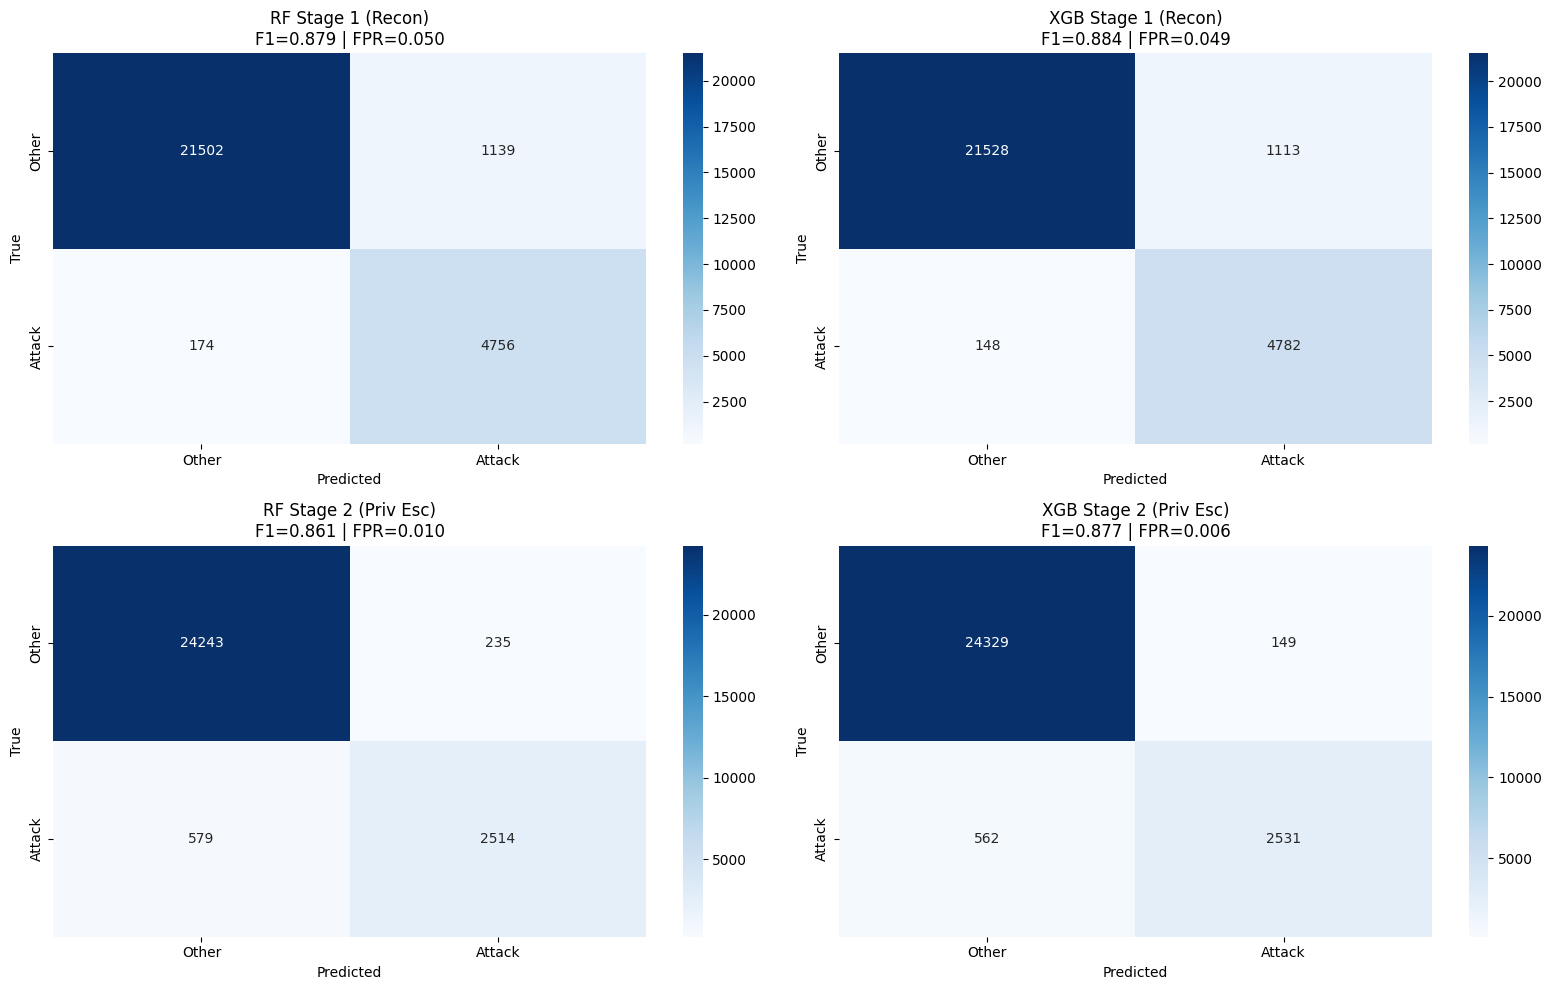

In [25]:
# ═══════════════════════════════════════════════════════════
# Confusion Matrices — Stage 1 & Stage 2 (RF vs XGB)
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models_cm = [
    (axes[0,0], 'RF Stage 1 (Recon)',     rf_s1,  X_te1,     y_te1),
    (axes[0,1], 'XGB Stage 1 (Recon)',    xgb_s1, X_te1_xgb, y_te1),
    (axes[1,0], 'RF Stage 2 (Priv Esc)',  rf_s2,  X_te2,     y_te2),
    (axes[1,1], 'XGB Stage 2 (Priv Esc)', xgb_s2, X_te2_xgb, y_te2),
]

for ax, lbl, model, X_te, y_te in models_cm:
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    fpr = cm[0,1] / (cm[0,0] + cm[0,1])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Other', 'Attack'], yticklabels=['Other', 'Attack'])
    ax.set_title(f"{lbl}\nF1={f1:.3f} | FPR={fpr:.3f}")
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices_v4.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Feature Importance

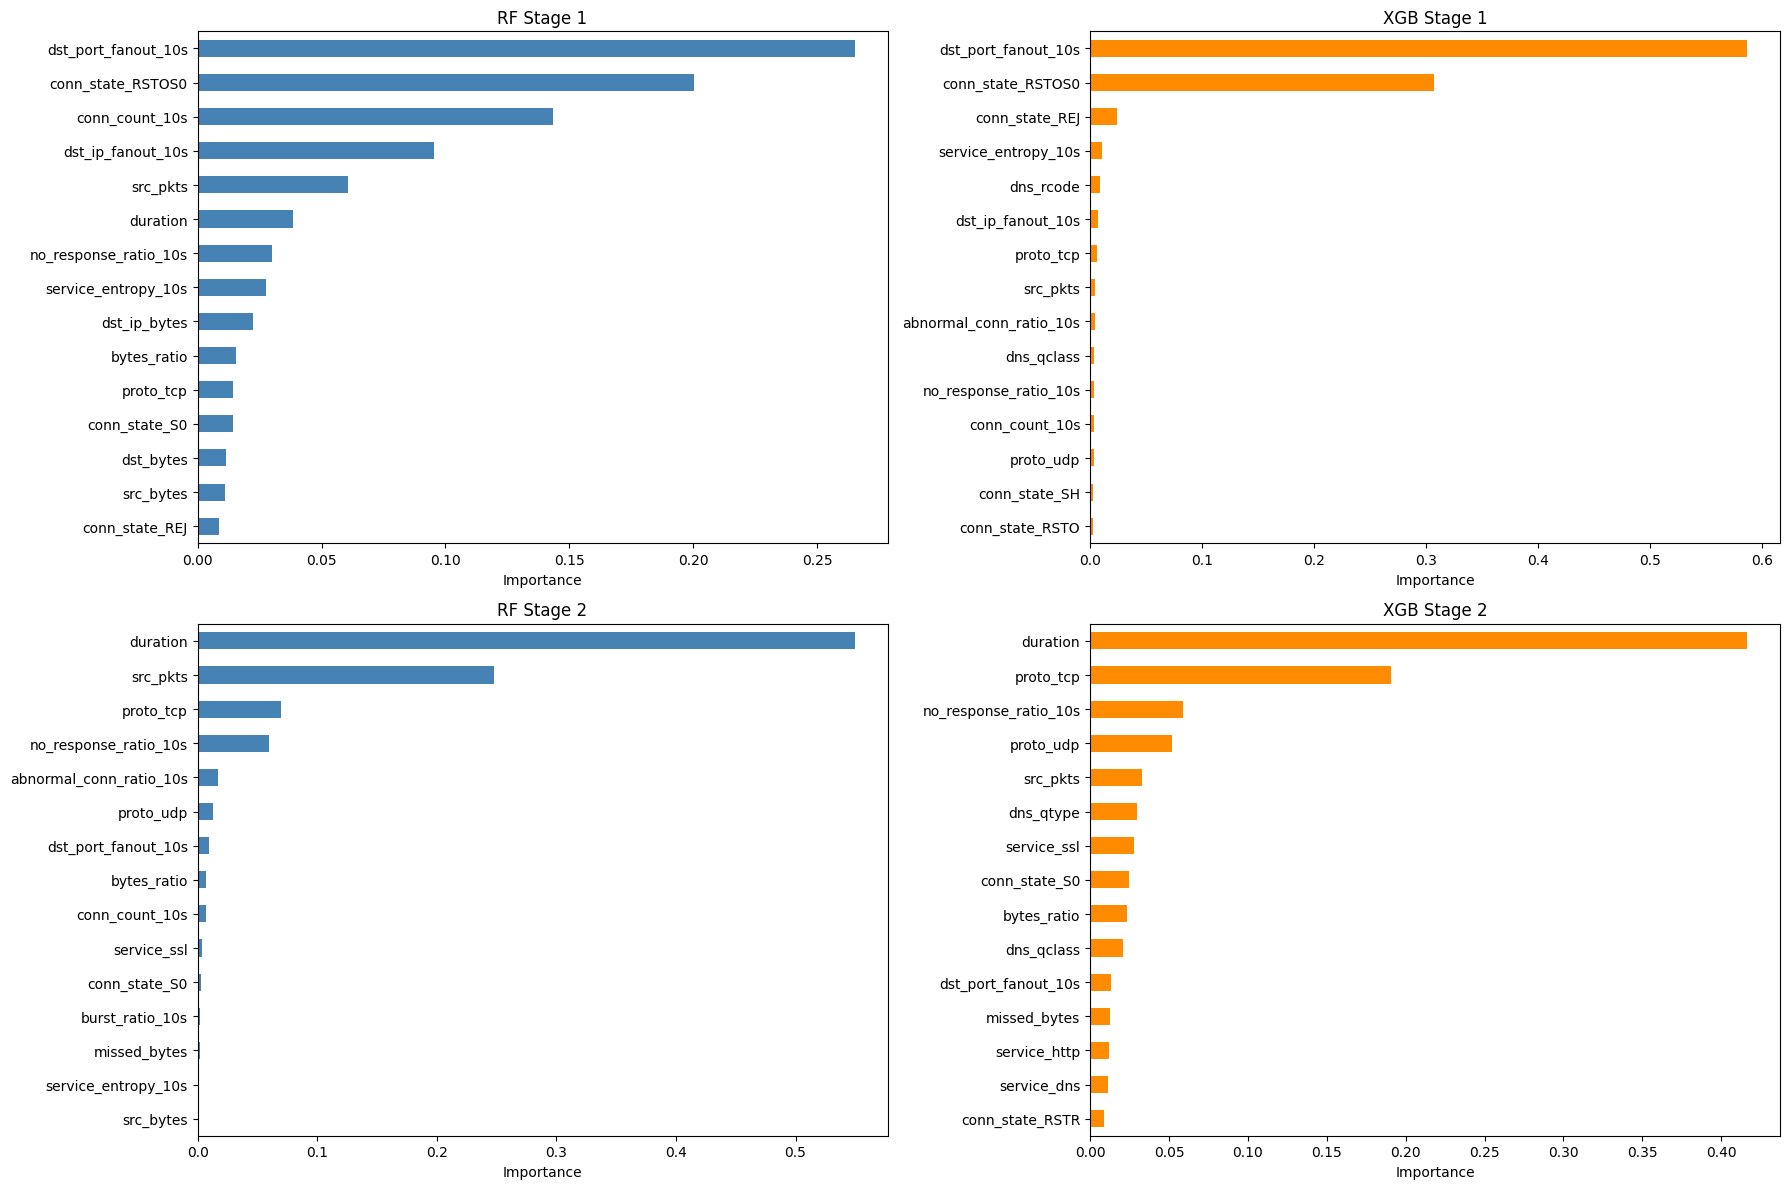

In [ ]:
# ═══════════════════════════════════════════════════════════
# Feature Importance — Stage 1 & 2 (RF vs XGB)
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

models_fi = [
    (axes[0,0], 'RF Stage 1',  rf_s1,  X_tr1,     'steelblue'),
    (axes[0,1], 'XGB Stage 1', xgb_s1, X_tr1_xgb, 'darkorange'),
    (axes[1,0], 'RF Stage 2',  rf_s2,  X_tr2,     'steelblue'),
    (axes[1,1], 'XGB Stage 2', xgb_s2, X_tr2_xgb, 'darkorange'),
]

all_imp_features = []
for ax, lbl, model, X_tr, color in models_fi:
    imp = pd.Series(model.feature_importances_, index=X_tr.columns).nlargest(15)
    imp.plot(kind='barh', ax=ax, color=color)
    ax.set_title(lbl)
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    # ensure global list of unique important features across models
    if 'all_imp_features' not in globals():
        all_imp_features = []
    for col in imp.index:
        if col not in all_imp_features:
            all_imp_features.append(col)

plt.tight_layout()
plt.savefig('feature_importance_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# PREDICTION SETUP
---

## 11. Dataset creation

### Stage aware

#### Entity-Level Feature Construction

##### General Aggregation

In [27]:
def aggregate_by_dst_ip(dftest, stage_num=3):
    # Aggregate by destination IP using actual columns
    agg_dict = {}

    # Identify numeric and categorical columns
    numeric_cols = []
    categorical_cols = []
    for col in dftest.columns:
        if col != 'dst_ip':
            if dftest[col].dtype in ['int64', 'float64'] and col != 'stage':
                numeric_cols.append(col)
                agg_dict[col] = ['sum', 'mean', 'min', 'max', 'std']
            elif col == 'stage':
                # For 'stage': 1 if this dst_ip ever appears at stage_num, else 0
                agg_dict[col] = lambda x: 1 if (x == stage_num).any() else 0
            else:
                categorical_cols.append(col)

    # First aggregation for numeric columns
    dftest_agg = dftest.groupby('dst_ip').agg(agg_dict)
    # one honest flow count per dst_ip (replaces the ~20 redundant *_count cols)
    dftest_agg['flow_count'] = dftest.groupby('dst_ip').size()

    # Flatten numeric column names (keep 'stage' as is)
    dftest_agg.columns = ['stage' if col[0] == 'stage' else '_'.join(col).strip()
                          for col in dftest_agg.columns.values]

    # Categorical (one-hot dummy) columns: emit ONE column per dummy.
    # The dummy is already 0/1, so count-of-1s is the only non-redundant value
    # (count-of-0s = flow_count - count-of-1s, already captured by flow_count).
    for cat_col in categorical_cols:
        col_int = dftest[cat_col].astype(int)              # local, no in-place mutation
        uniq = set(col_int.dropna().unique())
        if uniq.issubset({0, 1}):
            # binary dummy -> single count of present (==1)
            dftest_agg[f"{cat_col}_count"] = col_int.groupby(dftest['dst_ip']).sum()
        else:
            # genuine multi-value categorical -> keep per-value counts (no redundancy here)
            vc = col_int.groupby(dftest['dst_ip']).value_counts().unstack(fill_value=0)
            vc.columns = [f"{cat_col}_{val}_count" for val in vc.columns]
            dftest_agg = dftest_agg.join(vc)

    # Round numeric columns
    dftest_agg = dftest_agg.round(4)
    return dftest_agg

In [28]:
def _future_stage3_victims(df_future, stage=3):
    """dst_ips that are victimised at `stage` in the FUTURE window (label source)."""
    return set(df_future.loc[df_future['stage'] == stage, 'dst_ip'].unique())


def _label_entities_by_future(entity_agg, victims, label_col='stage'):
    """Overwrite the aggregated `stage` column with the PREDICTION label:
    1 if this dst_ip is a future stage-3 victim, else 0. The aggregated `stage`
    coming out of aggregate_by_dst_ip is all-zero by construction here (df_past
    has no stage-3 flows) and is discarded."""
    out = entity_agg.copy()
    out.index.name = 'dst_ip'
    out[label_col] = out.index.to_series().isin(victims).astype(int).values
    return out


def build_stage3_dataset(df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2,
                         ef_raw_train=None, ef_raw_test=None):
    """Stage-3 PREDICTION dataset, STAGE-AWARE (v6).

    Features come from PAST flows only (df_test_past): general aggregation
    (aggregate_by_dst_ip) + raw entity features (ef_raw_train) + Stage-1/2
    detector probabilities + proba entity features (entity_features_proba).
    Labels come from df_future via future stage-3 victims.

    Returns ONE labelled entity frame (one row per dst_ip); the train/val/test
    split happens downstream. df_future is used ONLY to derive labels — it is
    never aggregated into features. `ef_raw_test` is accepted for signature
    compatibility and intentionally unused.

    NOTE: feature-creation functions (aggregate_by_dst_ip, entity_features_*)
    are unchanged — only dataset assembly + labelling changed.
    """
    assert 'dst_ip' in df_test_past.columns, "dst_ip missing from df_test_past"
    assert 'dst_ip' in df_future.columns,    "dst_ip missing from df_future"

    past = df_test_past.copy()

    NON_FEATURE_COLS = ['dst_ip', 'stage']
    def make_X(df, ref):
        return df.drop(columns=NON_FEATURE_COLS, errors='ignore').reindex(columns=ref, fill_value=0)

    # 1. Attach Stage-1/2 detector probabilities (PAST only — honest: rf_s1/rf_s2
    #    were trained on df_train_past, not df_test_past).
    past['stage_1_proba'] = pd.to_numeric(
        rf_s1.predict_proba(make_X(past, X_tr1.columns))[:, 1].astype(float), errors='coerce')
    past['stage_2_proba'] = pd.to_numeric(
        rf_s2.predict_proba(make_X(past, X_tr2.columns))[:, 1].astype(float), errors='coerce')

    # 2. Proba-dependent entity features (feature creation UNCHANGED)
    ef_pb_train = entity_features_proba(past)

    # 3. General aggregation (feature creation UNCHANGED)
    train_agg = aggregate_by_dst_ip(past, stage_num=3)

    # 4. Join entity features by dst_ip
    if ef_raw_train is not None:
        train_agg = train_agg.join(ef_raw_train)
    train_agg = train_agg.join(ef_pb_train)
    ef_cols = [c for c in train_agg.columns if c.startswith('ef_')]
    train_agg[ef_cols] = train_agg[ef_cols].fillna(0.0)

    # 5. LABEL from the FUTURE
    victims   = _future_stage3_victims(df_future, stage=3)
    train_agg = _label_entities_by_future(train_agg, victims)

    n_pos = int(train_agg['stage'].sum())
    print(f"\n[stage-aware] entity dataset : {train_agg.shape}  (one row per dst_ip)")
    print(f"  entity features added      : {len(ef_cols)}")
    print(f"  future S3 victims total    : {len(victims)}")
    print(f"  victims present as entities: {n_pos}   <-- positives available for split")
    miss = len(victims) - n_pos
    if miss > 0:
        print(f"  NOTE: {miss} future victim(s) never appeared in df_test_past "
              f"(no past behaviour to aggregate) -> not in dataset.")
    if n_pos < 6:
        print("  WARNING: <6 positives. A 3-way stratified split is extremely thin; "
              "rely on CV thresholding and report variance across seeds.")
    return train_agg


### Direct Predictions

In [29]:
def build_stage3_dataset_baseline(df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2,
                                  ef_raw_train=None, ef_raw_test=None):
    """Stage-3 PREDICTION dataset, BASELINE (v6).

    Same as build_stage3_dataset but with NO detector probabilities and NO
    proba entity features. Features from PAST only; labels from FUTURE. Returns
    ONE labelled entity frame. rf_s1/rf_s2/X_tr1/X_tr2/ef_raw_test accepted for
    signature compatibility; only ef_raw_train (raw entity features) is used.
    """
    assert 'dst_ip' in df_test_past.columns
    assert 'dst_ip' in df_future.columns

    train_agg = aggregate_by_dst_ip(df_test_past.copy(), stage_num=3)
    if ef_raw_train is not None:
        train_agg = train_agg.join(ef_raw_train)
        ef_cols = [c for c in train_agg.columns if c.startswith('ef_')]
        train_agg[ef_cols] = train_agg[ef_cols].fillna(0.0)

    victims   = _future_stage3_victims(df_future, stage=3)
    train_agg = _label_entities_by_future(train_agg, victims)

    print(f"\n[baseline] entity dataset : {train_agg.shape}")
    print(f"  positives available     : {int(train_agg['stage'].sum())}")
    return train_agg


In [30]:
from sklearn.model_selection import train_test_split

def split_train_val_test(entity_df, label='stage', test_size=0.25, val_size=0.15,
                         random_state=42, min_pos_for_val=6, verbose=True):
    """Stratified entity-level train/val/test split for the Stage-3 PREDICTION
    dataset. dst_ip is the index and is carried through (never a feature).

    Hardened for Stage-3 positive scarcity (~13 victims total, fewer after the
    src_ip split). It NEVER raises on stratification — it adapts and reports:
      * < 2 positives total  -> raises with a clear remediation message
        (a stratified test set with a positive is impossible).
      * too few positives for a 3-way split -> degrades to train/test only
        (val empty); run_stage3 then picks the threshold via train CV.
      * otherwise -> full stratified train/val/test.

    Returns: X_train, X_val, X_test, y_train, y_val, y_test
    """
    y_all = entity_df[label].astype(int)
    X_all = entity_df.drop(columns=[label, 'dst_ip'], errors='ignore')
    n_pos = int(y_all.sum())

    if n_pos < 2:
        raise ValueError(
            f"Only {n_pos} positive entity(ies) in the dataset — cannot build a "
            f"stratified test set containing a positive. Options: build the entity "
            f"frame from ALL of df_past (not just df_test_past) and generate probas "
            f"out-of-fold, or lower the timesplit `guard`. See context MD 'Coverage caveat'.")

    # First carve the TEST set (always stratified, always has >=1 positive).
    X_tmp, X_test, y_tmp, y_test = train_test_split(
        X_all, y_all, test_size=test_size, stratify=y_all, random_state=random_state)

    # Try a VAL split only if there are enough positives to make it meaningful.
    X_val, y_val = X_tmp.iloc[:0], y_tmp.iloc[:0]
    want_val = bool(val_size and val_size > 0 and n_pos >= min_pos_for_val
                    and int(y_tmp.sum()) >= 2)
    if want_val:
        val_rel = val_size / (1.0 - test_size)
        try:
            X_train, X_val, y_train, y_val = train_test_split(
                X_tmp, y_tmp, test_size=val_rel, stratify=y_tmp, random_state=random_state)
        except ValueError:                       # too few positives for stratify
            X_train, y_train = X_tmp, y_tmp
            X_val, y_val = X_tmp.iloc[:0], y_tmp.iloc[:0]
    else:
        X_train, y_train = X_tmp, y_tmp

    has_val = len(y_val) > 0 and int(y_val.sum()) > 0
    if verbose:
        mode = ("train/val/test" if has_val else
                "train/test (val skipped: too few positives -> threshold via train-CV)")
        print(f"Stratified entity split [{mode}] (features=PAST, labels=FUTURE):")
        def s(n, yy): print(f"  {n:5s}: n={len(yy):>5}  pos={int(yy.sum()):>3}")
        s('train', y_train); s('val', y_val); s('test', y_test)

    assert int(y_test.sum()) > 0, "No positives reached the test set — lower test_size or pool df_past."
    return X_train, X_val, X_test, y_train, y_val, y_test


### 11.0 PREDICTION DATAFLOW (v6)

Stage 3 is now a **forecast**, not a detector:

1. `timesplit` cuts at `min(stage3 ts) - 1` &rarr; **df_past has zero stage-3 flows**.
2. The entity dataset is built from **df_test_past only** (past behaviour). df_future is used **only** to label which `dst_ip` becomes a stage-3 victim.
3. Detector probabilities + entity features are attached to the past frame.
4. One labelled entity frame &rarr; **stratified train/val/test split**.
5. Tune on train (CV), choose threshold on val, evaluate on the held-out test.

Features (past) and label (future) are temporally disjoint, so no stage-3 flow is ever visible while predicting stage-3 victimisation.

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# SHARED STAGE-3 TRAINER  (tune on train via CV, threshold on val, score on test)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve, auc,
                             precision_recall_fscore_support)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np


def _pick_threshold(y_true, y_proba):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    bi = int(np.argmax(f1))
    return (thr[bi] if bi < len(thr) else 0.5), f1[bi]


def _eval(y_true, y_pred, label):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    print(f"\n{'='*52}\n{label}\n{'='*52}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
    return {'f1': f1, 'precision': prec, 'recall': rec, 'fpr': fpr, 'cm': cm,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}


def run_stage3(X_train, y_train, X_val, y_val, X_test, y_test, title,
               save_as=None, n_iter=40, random_state=42):
    """Train + tune + evaluate one Stage-3 entity predictor.

    Protocol (leak-free):
      1. RandomizedSearchCV (StratifiedKFold) on TRAIN only -> hyperparameters.
      2. Decision threshold chosen on VAL (PR/F1). If VAL has no positives,
         fall back to out-of-fold CV probabilities on TRAIN.
      3. Final metrics reported on the untouched TEST set, at t=0.50 and t*.
    """
    print(f"X_train {X_train.shape} pos={int(y_train.sum())} | "
          f"X_val {X_val.shape} pos={int(y_val.sum())} | "
          f"X_test {X_test.shape} pos={int(y_test.sum())}")
    assert y_train.sum() > 0 and y_test.sum() > 0, "Need positives in train & test."

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    imb = neg / max(pos, 1)
    print(f"Train class ratio (neg:pos) = {imb:.1f}:1")

    param_dist = {
        'n_estimators'     : [100, 200, 300, 500],
        'max_depth'        : [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'max_features'     : ['sqrt', 'log2', 0.3],
        'class_weight'     : ['balanced', 'balanced_subsample',
                              {0: 1, 1: int(imb)}, {0: 1, 1: int(imb * 1.5)}],
    }
    n_splits = max(2, min(5, int(pos)))           # never more folds than positives
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    search = RandomizedSearchCV(
        RandomForestClassifier(random_state=random_state, n_jobs=-1),
        param_distributions=param_dist, n_iter=n_iter, scoring='f1',
        cv=cv, random_state=random_state, n_jobs=-1, verbose=1, refit=True)
    print(f"\nRandomizedSearchCV ({n_iter} iters x {n_splits}-fold) ...")
    search.fit(X_train, y_train)
    print(f"Best CV F1 : {search.best_score_:.4f}\nBest params: {search.best_params_}")
    rf = search.best_estimator_

    # ── threshold selection ──────────────────────────────────────────────────
    if len(y_val) > 0 and y_val.sum() > 0:
        thr, thr_f1 = _pick_threshold(y_val, rf.predict_proba(X_val)[:, 1])
        thr_src = f"VAL (F1={thr_f1:.3f})"
    else:
        oof = cross_val_predict(rf, X_train, y_train, cv=cv,
                                method='predict_proba', n_jobs=-1)[:, 1]
        thr, thr_f1 = _pick_threshold(y_train, oof)
        thr_src = f"TRAIN-CV oof (F1={thr_f1:.3f})"
    print(f"\nChosen threshold: {thr:.4f}  [from {thr_src}]")

    # ── evaluate on TEST ─────────────────────────────────────────────────────
    proba_te = rf.predict_proba(X_test)[:, 1]
    res_def = _eval(y_test, (proba_te >= 0.50).astype(int), f"{title} — t=0.50")
    res_opt = _eval(y_test, (proba_te >= thr).astype(int),  f"{title} — t={thr:.3f}")

    # ── figures ──────────────────────────────────────────────────────────────
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, proba_te)
    pr_auc = auc(rec_arr, prec_arr)
    fpr_roc, tpr_roc, _ = roc_curve(y_test, proba_te)
    roc_auc = auc(fpr_roc, tpr_roc)

    fig = plt.figure(figsize=(20, 12))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
    a1 = fig.add_subplot(gs[0, 0]); sns.heatmap(res_def['cm'], annot=True, fmt='d', cmap='Blues', ax=a1,
        xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
    a1.set_title(f"CM t=0.50\nF1={res_def['f1']:.3f} FPR={res_def['fpr']:.3f}"); a1.set_ylabel('True'); a1.set_xlabel('Pred')
    a2 = fig.add_subplot(gs[0, 1]); sns.heatmap(res_opt['cm'], annot=True, fmt='d', cmap='Greens', ax=a2,
        xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
    a2.set_title(f"CM t={thr:.3f}\nF1={res_opt['f1']:.3f} FPR={res_opt['fpr']:.3f}"); a2.set_ylabel('True'); a2.set_xlabel('Pred')
    a3 = fig.add_subplot(gs[0, 2]); a3.plot(rec_arr, prec_arr, 'b-', lw=2)
    a3.set_xlabel('Recall'); a3.set_ylabel('Precision'); a3.set_title(f'PR curve  AUC-PR={pr_auc:.4f}'); a3.grid(True, alpha=0.3)
    a5 = fig.add_subplot(gs[1, 0]); a5.plot(fpr_roc, tpr_roc, 'b-', lw=2, label=f'AUC={roc_auc:.4f}')
    a5.plot([0, 1], [0, 1], 'k--', alpha=0.4); a5.set_xlabel('FPR'); a5.set_ylabel('TPR'); a5.set_title('ROC'); a5.legend(); a5.grid(True, alpha=0.3)
    a6 = fig.add_subplot(gs[1, 1:]); pd.Series(rf.feature_importances_, index=X_train.columns).nlargest(20).plot(kind='barh', ax=a6, color='steelblue')
    a6.set_title('Top 20 feature importances'); a6.invert_yaxis(); a6.set_xlabel('Importance')
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight')
    plt.show()

    print("\n" + "=" * 56)
    print(f"SUMMARY — {title}")
    print(f"  CV F1 (train)   : {search.best_score_:.4f}")
    print(f"  Test F1 t=0.50  : {res_def['f1']:.4f}   Rec={res_def['recall']:.4f}  FPR={res_def['fpr']:.4f}")
    print(f"  Test F1 t={thr:.3f}: {res_opt['f1']:.4f}   Rec={res_opt['recall']:.4f}  FPR={res_opt['fpr']:.4f}")
    print(f"  AUC-ROC={roc_auc:.4f}  AUC-PR={pr_auc:.4f}")
    print("=" * 56)
    return rf, {'default': res_def, 'optimal': res_opt, 'threshold': thr,
                'pr_auc': pr_auc, 'roc_auc': roc_auc, 'cv_f1': search.best_score_,
                'best_params': search.best_params_}


#### Call Function

In [32]:
# ── Build PREDICTION datasets (features = PAST, labels = FUTURE) ──────────────
entity_aware = build_stage3_dataset(
    df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2,
    ef_raw_train=ef_raw_train, ef_raw_test=ef_raw_test)

entity_base = build_stage3_dataset_baseline(
    df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2,
    ef_raw_train=ef_raw_train, ef_raw_test=ef_raw_test)

# ── Split ONCE (stage-aware), then apply the SAME partition to the baseline ──
# so stage-aware vs baseline differ only in features, not in which entities
# land in train/val/test. Both frames share the same dst_ip index ordering
# (aggregate_by_dst_ip groups+sorts by dst_ip).
X_tr3, X_val3, X_te3, y_tr3, y_val3, y_te3 = split_train_val_test(entity_aware)
idx_tr, idx_val, idx_te = X_tr3.index, X_val3.index, X_te3.index

def _apply_split(entity_df):
    y = entity_df['stage'].astype(int)
    X = entity_df.drop(columns=['stage', 'dst_ip'], errors='ignore')
    return (X.loc[idx_tr], X.loc[idx_val], X.loc[idx_te],
            y.loc[idx_tr], y.loc[idx_val], y.loc[idx_te])

X_tr3_base, X_val3_base, X_te3_base, y_tr3_base, y_val3_base, y_te3_base = _apply_split(entity_base)

print(f"\nStage-aware features: {X_tr3.shape[1]} | Baseline features: {X_tr3_base.shape[1]}")
print(f"Train pos={int(y_tr3.sum())} | Val pos={int(y_val3.sum())} | Test pos={int(y_te3.sum())}")



[stage-aware] entity dataset : (349, 129)  (one row per dst_ip)
  entity features added      : 4
  future S3 victims total    : 13
  victims present as entities: 9   <-- positives available for split
  NOTE: 4 future victim(s) never appeared in df_test_past (no past behaviour to aggregate) -> not in dataset.

[baseline] entity dataset : (349, 117)
  positives available     : 9
Stratified entity split [train/val/test] (features=PAST, labels=FUTURE):
  train: n=  208  pos=  6
  val  : n=   53  pos=  1
  test : n=   88  pos=  2

Stage-aware features: 128 | Baseline features: 116
Train pos=6 | Val pos=1 | Test pos=2


# STAGE 3 PREDICTIONS

feat. hyperparameter and threshold tuning

## Stage aware

X_train (208, 128) pos=6 | X_val (53, 128) pos=1 | X_test (88, 128) pos=2
Train class ratio (neg:pos) = 33.7:1

RandomizedSearchCV (40 iters x 5-fold) ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV F1 : 0.1333
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': None, 'class_weight': 'balanced_subsample'}

Chosen threshold: 0.3774  [from VAL (F1=0.667)]

Stage 3 — Entity Under Threat (stage-aware) — t=0.50
F1=0.6667  Prec=1.0000  Rec=0.5000  FPR=0.0000
TN=86 FP=0 FN=1 TP=1

Stage 3 — Entity Under Threat (stage-aware) — t=0.377
F1=0.6667  Prec=1.0000  Rec=0.5000  FPR=0.0000
TN=86 FP=0 FN=1 TP=1


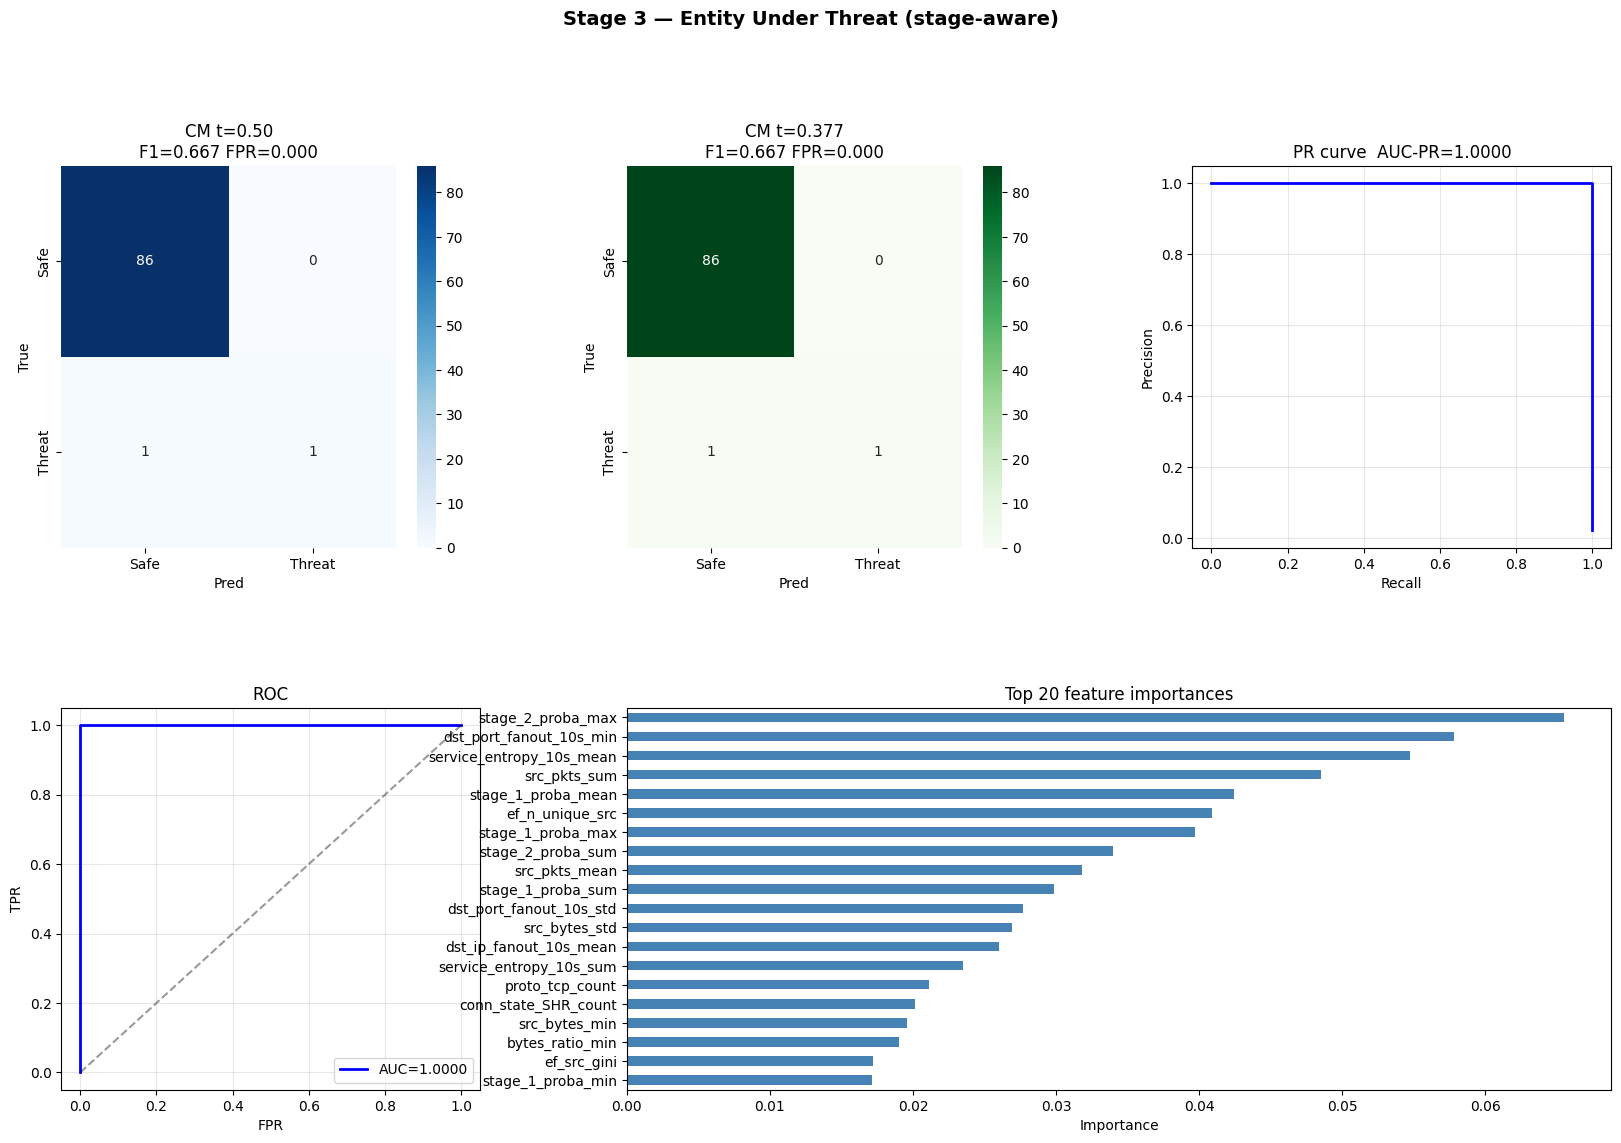


SUMMARY — Stage 3 — Entity Under Threat (stage-aware)
  CV F1 (train)   : 0.1333
  Test F1 t=0.50  : 0.6667   Rec=0.5000  FPR=0.0000
  Test F1 t=0.377: 0.6667   Rec=0.5000  FPR=0.0000
  AUC-ROC=1.0000  AUC-PR=1.0000


In [33]:
# STAGE 3 — stage-aware. Tune on TRAIN (CV), pick threshold on VAL, evaluate on TEST.
rf_s3, res_s3 = run_stage3(
    X_tr3, y_tr3, X_val3, y_val3, X_te3, y_te3,
    title="Stage 3 — Entity Under Threat (stage-aware)",
    save_as="stage3_entity_underthreat_stageaware.png")


## Direct/Baseline


X_train (208, 116) pos=6 | X_val (53, 116) pos=1 | X_test (88, 116) pos=2
Train class ratio (neg:pos) = 33.7:1

RandomizedSearchCV (40 iters x 5-fold) ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV F1 : 0.1333
Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.3, 'max_depth': 15, 'class_weight': {0: 1, 1: 50}}

Chosen threshold: 0.5668  [from VAL (F1=1.000)]

Stage 3 — Entity Under Threat (baseline) — t=0.50
F1=0.6667  Prec=1.0000  Rec=0.5000  FPR=0.0000
TN=86 FP=0 FN=1 TP=1

Stage 3 — Entity Under Threat (baseline) — t=0.567
F1=0.6667  Prec=1.0000  Rec=0.5000  FPR=0.0000
TN=86 FP=0 FN=1 TP=1


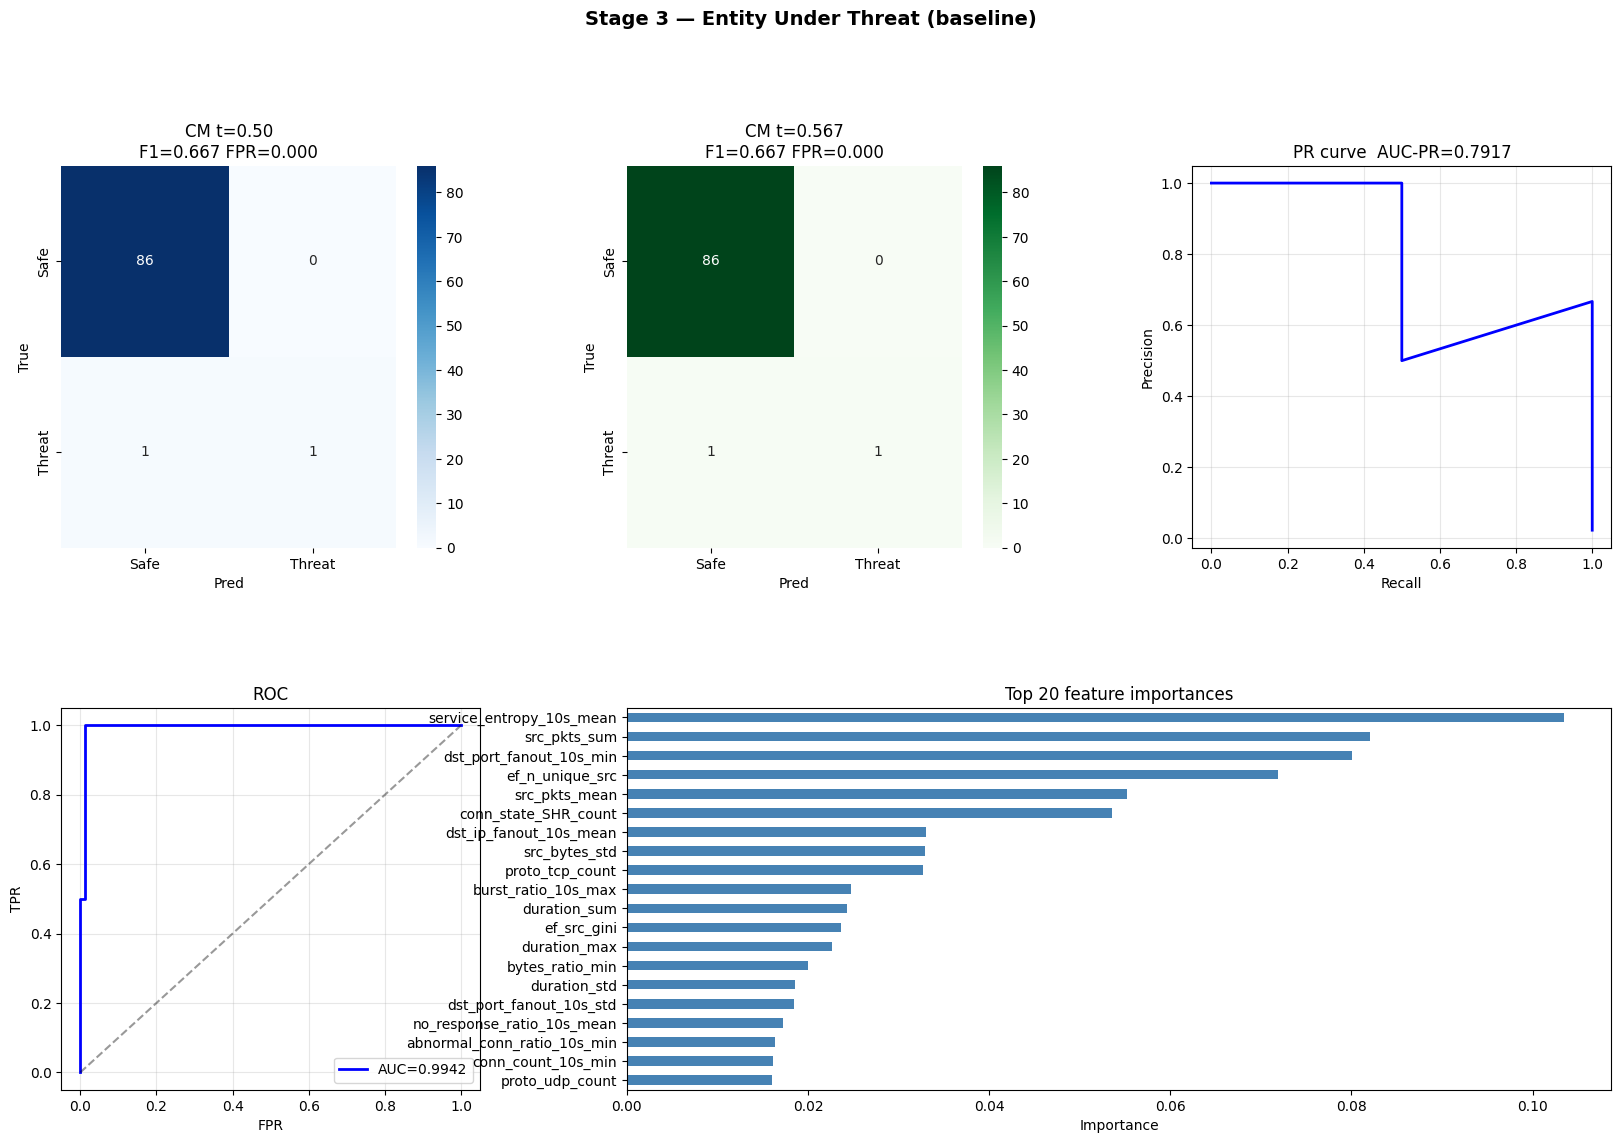


SUMMARY — Stage 3 — Entity Under Threat (baseline)
  CV F1 (train)   : 0.1333
  Test F1 t=0.50  : 0.6667   Rec=0.5000  FPR=0.0000
  Test F1 t=0.567: 0.6667   Rec=0.5000  FPR=0.0000
  AUC-ROC=0.9942  AUC-PR=0.7917


In [34]:
# STAGE 3 — baseline (no detector probas). Same protocol, SAME entity partition.
rf_s3_base, res_s3_base = run_stage3(
    X_tr3_base, y_tr3_base, X_val3_base, y_val3_base, X_te3_base, y_te3_base,
    title="Stage 3 — Entity Under Threat (baseline)",
    save_as="stage3_entity_underthreat_baseline.png")


# PREDICTION REVISIONS
Flow:

df_test_past -> aggregate by dst_ip -> for all dst_ip in df_test_past: attach df_future stage 3 label. -> New dataset


train-test split of new dataset -> train-val set -> Hyperparameter tuning -> Evaluations

## 11.5 Cross-Validated Stage-3 Evaluation (stratified K-fold)

Replaces the single train/val/test split for the final stage-aware vs baseline comparison. With ~9 positive entities, K-fold puts every positive in a held-out fold exactly once (out-of-fold prediction), giving a stable, paired comparison. Per-fold figures + a pooled out-of-fold summary are shown. Hyperparameters are fixed (imbalance-aware RF); tuning is skipped at this positive count. Bump `n_splits` or wrap in `RepeatedStratifiedKFold` to stabilize further.

In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE-3 CROSS-VALIDATED EVALUATION  (stratified K-fold, paired stage-aware/baseline)
# ──────────────────────────────────────────────────────────────────────────────
# Why: with only ~9 positive entities a single train/val/test split is unstable
# (a 1-entity swing moves recall by 0.33). K-fold puts every positive in a test
# fold exactly once, so all 9 get an out-of-fold (OOF) prediction. Both models
# share the SAME folds and SAME fixed RF hyperparameters, so the comparison is
# paired and fair. Tuning is deliberately skipped (option a) — at this positive
# count nested search adds noise, not signal.
# ══════════════════════════════════════════════════════════════════════════════


def _m(yt, p, thr):
    yp = (p >= thr).astype(int)
    pr, rc, f1, _ = precision_recall_fscore_support(yt, yp, average='binary', zero_division=0)
    cm = confusion_matrix(yt, yp, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
    return dict(f1=f1, precision=pr, recall=rc, fpr=fp/(fp+tn) if fp+tn else 0.0,
                cm=cm, tn=tn, fp=fp, fn=fn, tp=tp)

def run_stage3_cv(entity_aware, entity_base, label='stage', n_splits=3,
                  random_state=42, rf_params=None):
    """Paired stratified K-fold CV for stage-aware vs baseline Stage-3 predictors.
    Returns a dict with per-fold metrics, pooled out-of-fold metrics, and a
    shared operating threshold t* chosen from the pooled OOF PR curve."""
    if rf_params is None:
        rf_params = dict(n_estimators=300, max_depth=None, class_weight='balanced',
                         random_state=random_state, n_jobs=-1)
    assert (entity_aware.index == entity_base.index).all(), "frames must share dst_ip index order"
    y = entity_aware[label].astype(int).values
    X = {'stage-aware': entity_aware.drop(columns=[label, 'dst_ip'], errors='ignore'),
         'baseline'   : entity_base.drop(columns=[label, 'dst_ip'], errors='ignore')}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    R = {v: {'folds': [], 'oof': np.zeros(len(y))} for v in X}
    for f, (tr, te) in enumerate(skf.split(np.arange(len(y)), y)):
        for v in X:
            rf = RandomForestClassifier(**rf_params).fit(X[v].iloc[tr], y[tr])
            p = rf.predict_proba(X[v].iloc[te])[:, 1]; R[v]['oof'][te] = p; yt = y[te]
            prc, rcc, _ = precision_recall_curve(yt, p); fprc, tprc, _ = roc_curve(yt, p)
            m = _m(yt, p, 0.5)
            m.update(fold=f, n_test=len(yt), pos=int(yt.sum()), pr_auc=auc(rcc, prc),
                     roc_auc=auc(fprc, tprc), proba=p, ytrue=yt, n_train_pos=int(y[tr].sum()))
            R[v]['folds'].append(m)
    for v in X:
        oof = R[v]['oof']; prc, rcc, thr = precision_recall_curve(y, oof)
        f1c = 2*prc*rcc/(prc+rcc+1e-9); bi = int(np.nanargmax(f1c)); ts = thr[bi] if bi < len(thr) else 0.5
        fprc, tprc, _ = roc_curve(y, oof)
        R[v].update(pr_auc=auc(rcc, prc), roc_auc=auc(fprc, tprc), tstar=ts,
                    pooled_05=_m(y, oof, 0.5), pooled_opt=_m(y, oof, ts))
    R['_y'] = y
    return R

def report_cv(R):
    import pandas as pd
    rows = []
    for v in ['stage-aware', 'baseline']:
        for m in R[v]['folds']:
            rows.append(dict(variant=v, fold=m['fold'], test_n=m['n_test'], test_pos=m['pos'],
                             TP=m['tp'], FP=m['fp'], FN=m['fn'], TN=m['tn'],
                             recall=round(m['recall'],3), precision=round(m['precision'],3),
                             F1=round(m['f1'],3), FPR=round(m['fpr'],3),
                             PR_AUC=round(m['pr_auc'],3), ROC_AUC=round(m['roc_auc'],3)))
    pf = pd.DataFrame(rows)
    print("PER-FOLD (threshold = 0.50)\n", pf.to_string(index=False))
    print("\nPOOLED OUT-OF-FOLD (all positives)")
    for v in ['stage-aware', 'baseline']:
        a, b = R[v]['pooled_05'], R[v]['pooled_opt']
        print(f"  {v:12s} @0.50  rec={a['recall']:.3f} prec={a['precision']:.3f} F1={a['f1']:.3f} FPR={a['fpr']:.3f}")
        print(f"  {'':12s} @t*={R[v]['tstar']:.3f} rec={b['recall']:.3f} prec={b['precision']:.3f} F1={b['f1']:.3f} "
              f"FPR={b['fpr']:.3f} | AUC-PR={R[v]['pr_auc']:.3f} AUC-ROC={R[v]['roc_auc']:.3f}")
    return pf


In [36]:
# ── Per-fold + comparison visualizations ─────────────────────────────────────
def plot_cv_perfold(R, variant, color, tstar=None):
    tstar = R[variant]['tstar'] if tstar is None else tstar
    folds = R[variant]['folds']; n = len(folds)
    fig, ax = plt.subplots(n, 3, figsize=(15, 4.3*n))
    if n == 1: ax = ax.reshape(1, -1)
    for f, m in enumerate(folds):
        yt, p = m['ytrue'], m['proba']
        cm = confusion_matrix(yt, (p >= tstar).astype(int), labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[f,0],
                    xticklabels=['Safe','Threat'], yticklabels=['Safe','Threat'])
        tn,fp,fn,tp = cm.ravel(); rec = tp/(tp+fn) if tp+fn else 0
        ax[f,0].set_title(f"Fold {f}  CM @ t*={tstar:.2f}\nrecall={rec:.2f} ({tp}/{tp+fn})  FP={fp}")
        ax[f,0].set_ylabel('True'); ax[f,0].set_xlabel('Pred')
        pr,rc,_ = precision_recall_curve(yt,p)
        ax[f,1].plot(rc,pr,color=color,lw=2); ax[f,1].set_ylim(-.02,1.05); ax[f,1].grid(alpha=.3)
        ax[f,1].set_title(f"Fold {f}  PR (AUC-PR={m['pr_auc']:.3f})"); ax[f,1].set_xlabel('Recall'); ax[f,1].set_ylabel('Precision')
        fpr,tpr,_ = roc_curve(yt,p)
        ax[f,2].plot(fpr,tpr,color=color,lw=2,label=f"AUC={m['roc_auc']:.3f}"); ax[f,2].plot([0,1],[0,1],'k--',alpha=.4)
        ax[f,2].set_title(f"Fold {f}  ROC"); ax[f,2].set_xlabel('FPR'); ax[f,2].set_ylabel('TPR'); ax[f,2].legend(loc='lower right'); ax[f,2].grid(alpha=.3)
    fig.suptitle(f"Stage 3 — {variant}: per-fold evaluation ({n}-fold stratified CV)", fontsize=14, fontweight='bold', y=1.003)
    plt.tight_layout(); plt.show()

def plot_cv_comparison(R):
    y = R['_y']; fig = plt.figure(figsize=(16,10)); G = gridspec.GridSpec(2,3,figure=fig,hspace=.35,wspace=.32)
    for j,(v,cmap) in enumerate([('stage-aware','Blues'),('baseline','Reds')]):
        a=fig.add_subplot(G[0,j]); m=R[v]['pooled_opt']
        sns.heatmap(m['cm'],annot=True,fmt='d',cmap=cmap,cbar=False,ax=a,xticklabels=['Safe','Threat'],yticklabels=['Safe','Threat'])
        a.set_title(f"{v} — pooled OOF @ t*={R[v]['tstar']:.2f}\nrec={m['recall']:.2f} prec={m['precision']:.2f} F1={m['f1']:.2f} FPR={m['fpr']:.3f}")
        a.set_ylabel('True'); a.set_xlabel('Pred')
    a=fig.add_subplot(G[0,2]); fa=[m['recall'] for m in R['stage-aware']['folds']]; fb=[m['recall'] for m in R['baseline']['folds']]
    x=np.arange(len(fa)); w=.38; a.bar(x-w/2,fa,w,label='stage-aware',color='steelblue'); a.bar(x+w/2,fb,w,label='baseline',color='indianred')
    a.set_xticks(x); a.set_xticklabels([f'Fold{i}' for i in x]); a.set_ylim(0,1.05); a.set_title('Per-fold recall @ 0.50'); a.set_ylabel('recall'); a.legend()
    a=fig.add_subplot(G[1,0])
    for v,c in [('stage-aware','steelblue'),('baseline','indianred')]:
        pr,rc,_=precision_recall_curve(y,R[v]['oof']); a.plot(rc,pr,c,lw=2,label=f"{v} (AUC-PR={R[v]['pr_auc']:.3f})")
    a.set_xlabel('Recall'); a.set_ylabel('Precision'); a.set_title('Pooled OOF PR'); a.legend(); a.grid(alpha=.3); a.set_ylim(-.02,1.05)
    a=fig.add_subplot(G[1,1])
    for v,c in [('stage-aware','steelblue'),('baseline','indianred')]:
        fpr,tpr,_=roc_curve(y,R[v]['oof']); a.plot(fpr,tpr,c,lw=2,label=f"{v} (AUC={R[v]['roc_auc']:.3f})")
    a.plot([0,1],[0,1],'k--',alpha=.4); a.set_xlabel('FPR'); a.set_ylabel('TPR'); a.set_title('Pooled OOF ROC'); a.legend(loc='lower right'); a.grid(alpha=.3)
    a=fig.add_subplot(G[1,2]); a.axis('off'); t="POOLED OUT-OF-FOLD\n\n"
    for v in ['stage-aware','baseline']:
        o=R[v]['pooled_opt']; d=R[v]['pooled_05']
        t+=f"{v}\n  @0.50 : rec {d['recall']:.2f} F1 {d['f1']:.2f}\n  @t*{R[v]['tstar']:.2f}: rec {o['recall']:.2f} prec {o['precision']:.2f} F1 {o['f1']:.2f}\n  AUC-PR {R[v]['pr_auc']:.2f}  AUC-ROC {R[v]['roc_auc']:.2f}\n\n"
    a.text(0,1,t,va='top',ha='left',fontsize=11,family='monospace')
    fig.suptitle("Stage 3 — stage-aware vs baseline (paired stratified CV)",fontsize=14,fontweight='bold',y=1.01)
    plt.tight_layout(); plt.show()


PER-FOLD (threshold = 0.50)
     variant  fold  test_n  test_pos  TP  FP  FN  TN  recall  precision  F1  FPR  PR_AUC  ROC_AUC
stage-aware     0     117         3   1   0   2 114   0.333        1.0 0.5  0.0   0.764    0.982
stage-aware     1     116         3   1   0   2 113   0.333        1.0 0.5  0.0   0.569    0.979
stage-aware     2     116         3   0   0   3 113   0.000        0.0 0.0  0.0   1.000    1.000
   baseline     0     117         3   1   0   2 114   0.333        1.0 0.5  0.0   0.619    0.978
   baseline     1     116         3   1   0   2 113   0.333        1.0 0.5  0.0   0.539    0.973
   baseline     2     116         3   0   0   3 113   0.000        0.0 0.0  0.0   1.000    1.000

POOLED OUT-OF-FOLD (all positives)
  stage-aware  @0.50  rec=0.222 prec=1.000 F1=0.364 FPR=0.000
               @t*=0.213 rec=0.667 prec=0.750 F1=0.706 FPR=0.006 | AUC-PR=0.705 AUC-ROC=0.977
  baseline     @0.50  rec=0.222 prec=1.000 F1=0.364 FPR=0.000
               @t*=0.240 rec=0.667 pre

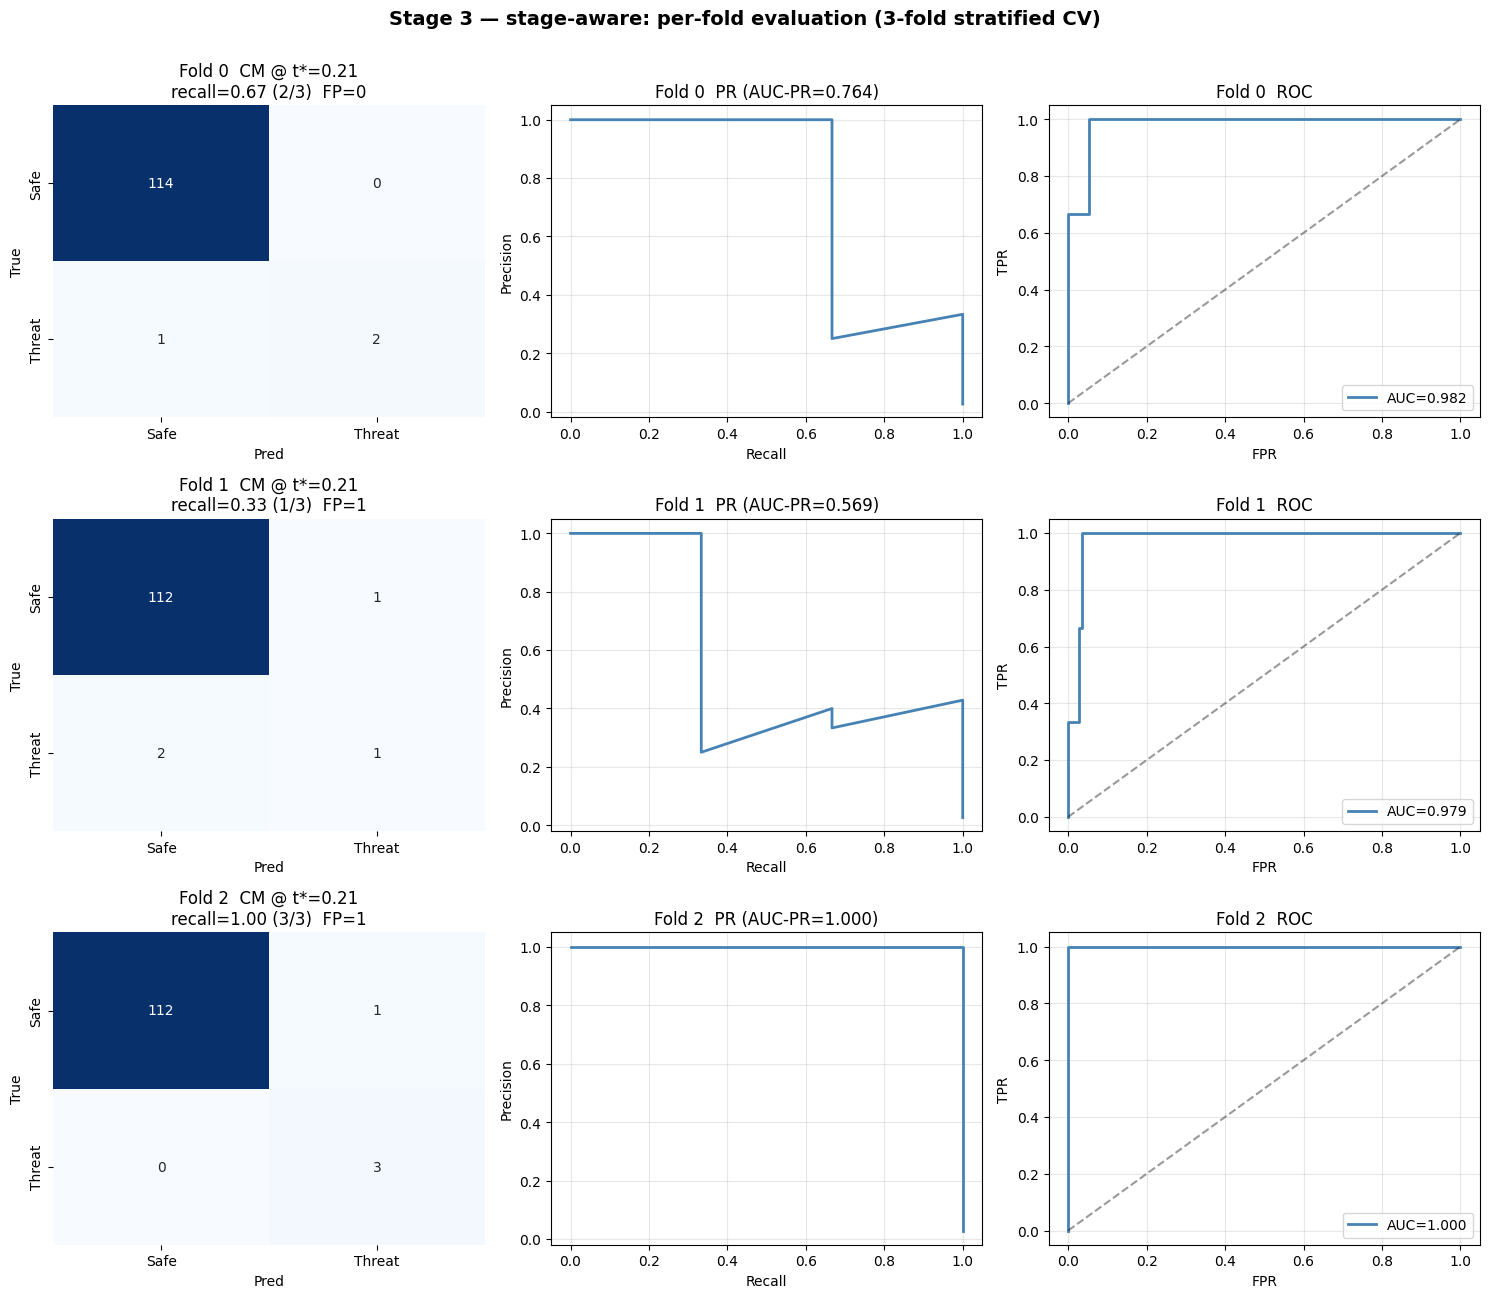

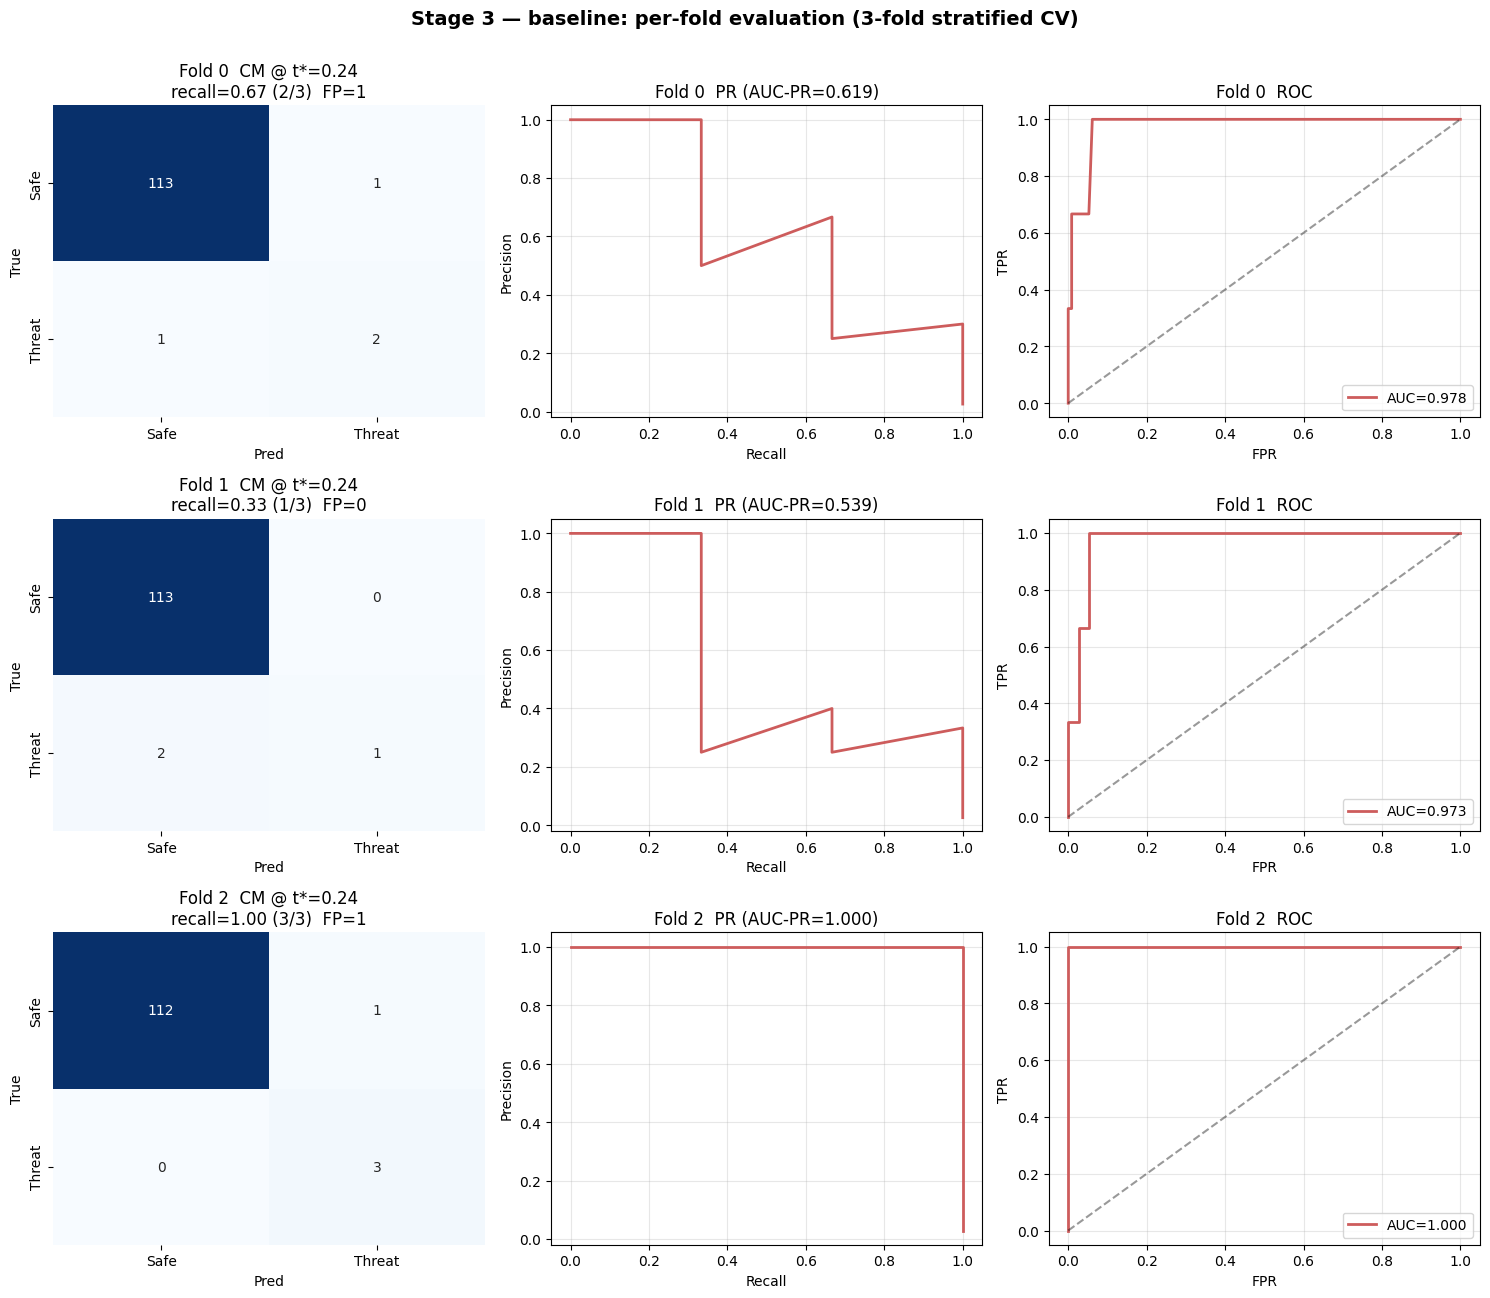

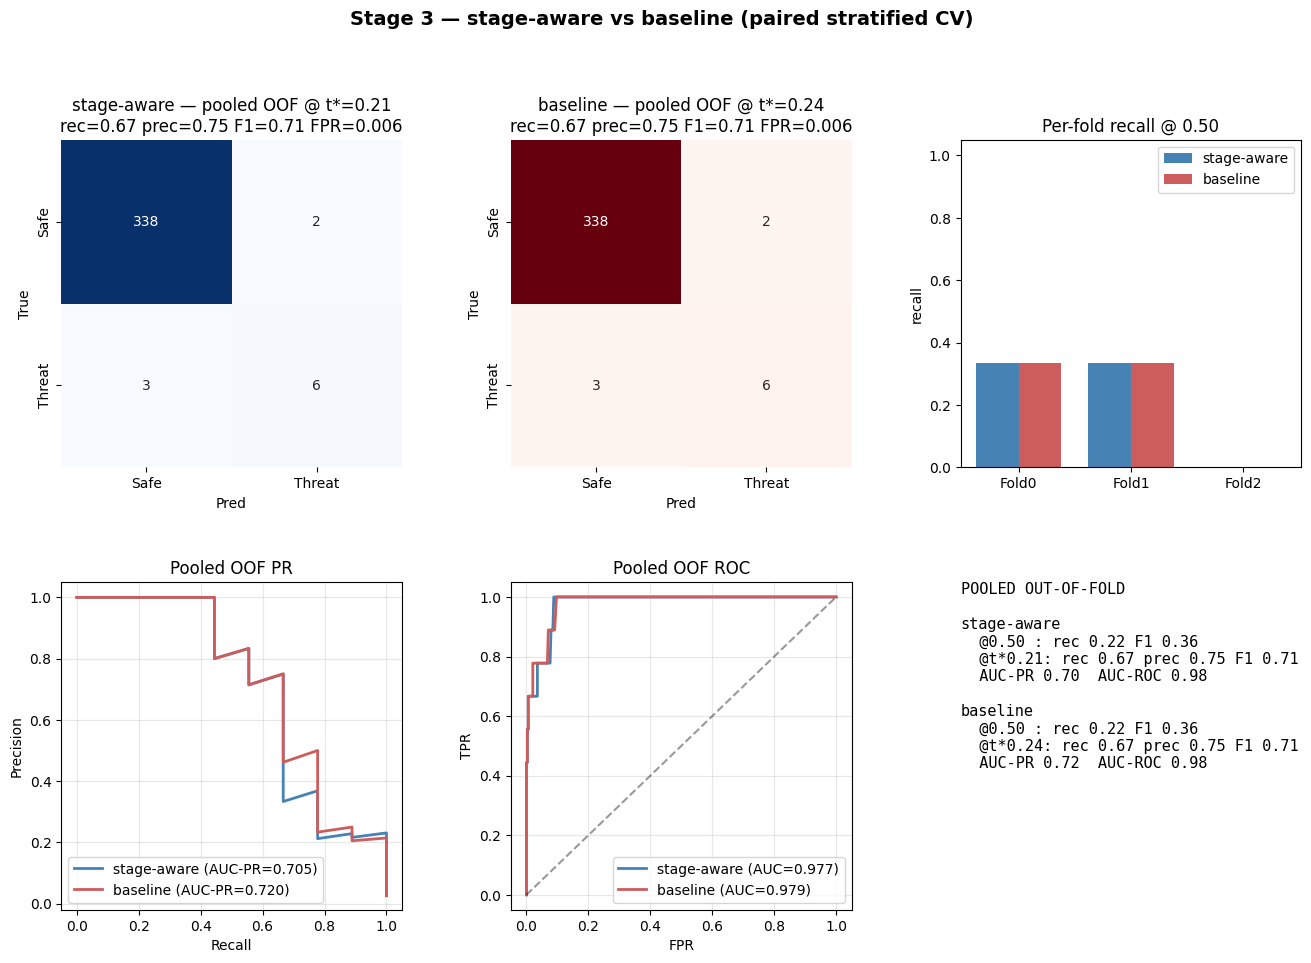

In [37]:
# Run 3-fold CV and visualize all folds + the pooled comparison.
R_cv = run_stage3_cv(entity_aware, entity_base, n_splits=3, random_state=42)
pf_cv = report_cv(R_cv)
plot_cv_perfold(R_cv, 'stage-aware', 'steelblue')
plot_cv_perfold(R_cv, 'baseline',    'indianred')
plot_cv_comparison(R_cv)
